In [52]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [53]:
df=pd.read_csv("emi_prediction_dataset.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_6580\335177974.py:1: DtypeWarning: Columns (0: age) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("emi_prediction_dataset.csv")


In [54]:
df.shape

(404800, 27)

# Data Cleaning

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  str    
 2   marital_status          404800 non-null  str    
 3   education               402396 non-null  str    
 4   monthly_salary          404800 non-null  str    
 5   employment_type         404800 non-null  str    
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  str    
 8   house_type              404800 non-null  str    
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses         404800 

In [56]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


### Datatypes of age and monthly_salary are string but it numerical type so we convert into integer and float

In [72]:

dataset =df.copy()
dataset["age"] = pd.to_numeric(
    dataset["age"], errors="coerce"
).astype("Int64")

dataset["monthly_salary"] = pd.to_numeric(
    dataset["monthly_salary"], errors="coerce"
)

In [73]:
dataset.duplicated().sum()

np.int64(0)

In [74]:
dataset[['age','monthly_salary']].dtypes

age                 Int64
monthly_salary    float64
dtype: object

In [100]:
dataset["gender"] = dataset["gender"].replace({
    "MALE": "Male",
    "male": "Male",
    "M": "Male",
    "F": "Female",
    "female": "Female",
    "FEMALE": "Female"
})

In [101]:
dataset["bank_balance"] = (
    dataset["bank_balance"]
    .astype(str)
    .str.replace(r"\.0\.0$", ".0", regex=True)
)

dataset["bank_balance"] = pd.to_numeric(
    dataset["bank_balance"],
    errors="coerce"
)

In [102]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404797 non-null  Int64  
 1   gender                  404800 non-null  str    
 2   marital_status          404800 non-null  str    
 3   education               402396 non-null  str    
 4   monthly_salary          402807 non-null  float64
 5   employment_type         404800 non-null  str    
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  str    
 8   house_type              404800 non-null  str    
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses         404800 

## EDA

## Missing value check

In [103]:
feature_nan=[feature for feature in dataset.columns if dataset[feature].isnull().sum()>1]

In [104]:
feature_nan

['age',
 'education',
 'monthly_salary',
 'monthly_rent',
 'credit_score',
 'bank_balance',
 'emergency_fund']

In [105]:
for feature in feature_nan:
    print(f"Total Missing value in {feature} feature is {dataset[feature].isnull().sum()}")

Total Missing value in age feature is 3
Total Missing value in education feature is 2404
Total Missing value in monthly_salary feature is 1993
Total Missing value in monthly_rent feature is 2426
Total Missing value in credit_score feature is 2420
Total Missing value in bank_balance feature is 2447
Total Missing value in emergency_fund feature is 2351


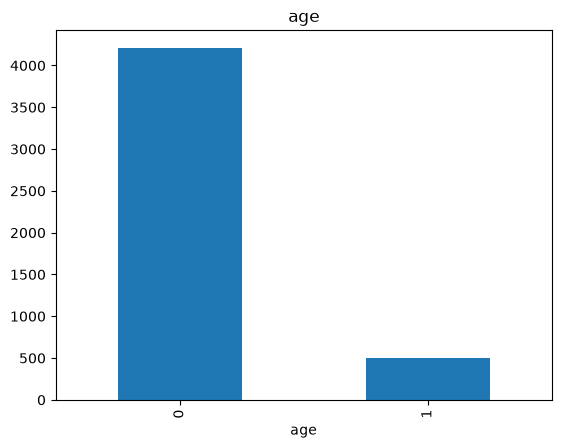

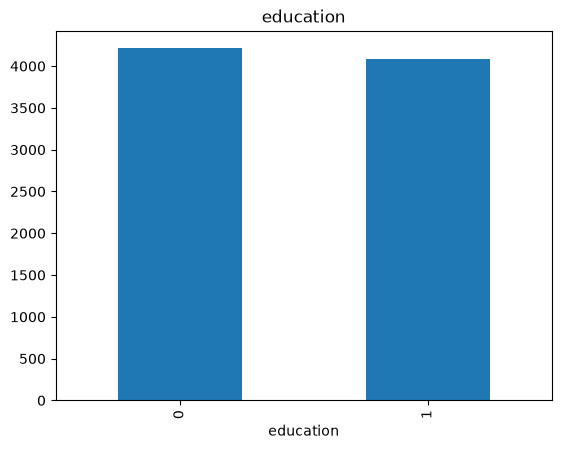

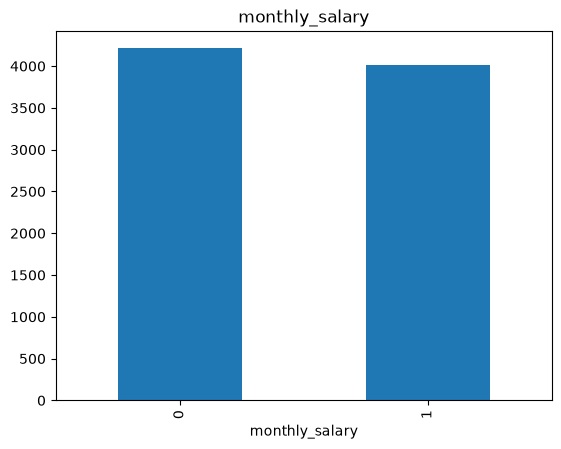

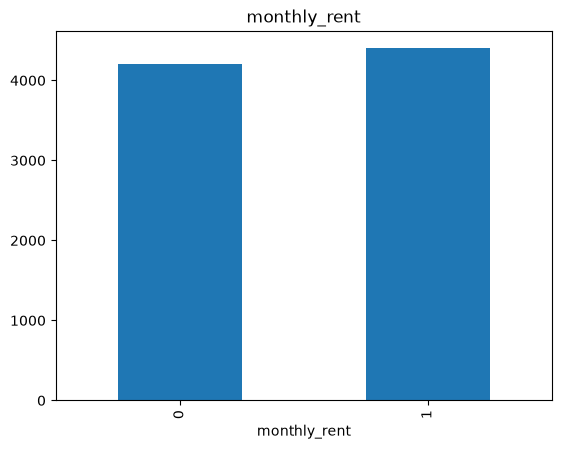

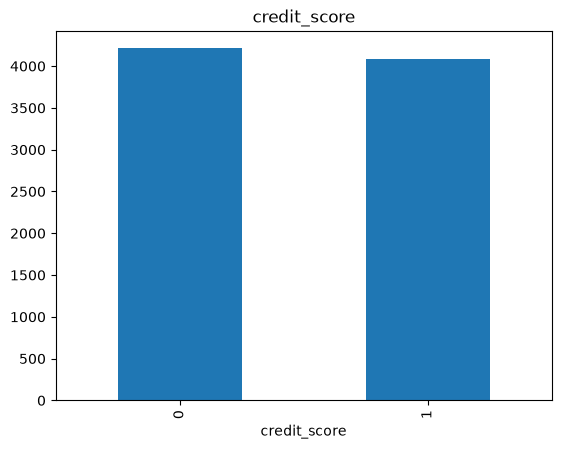

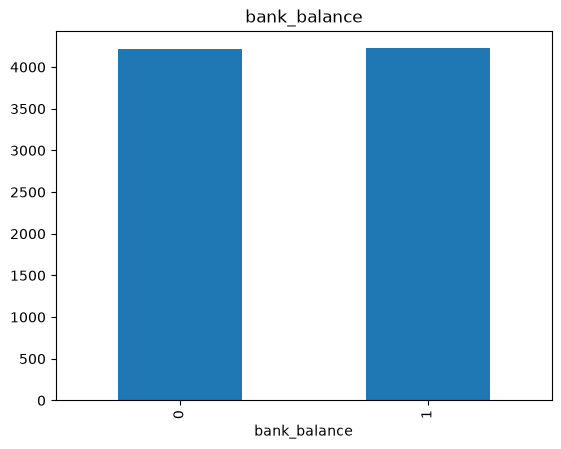

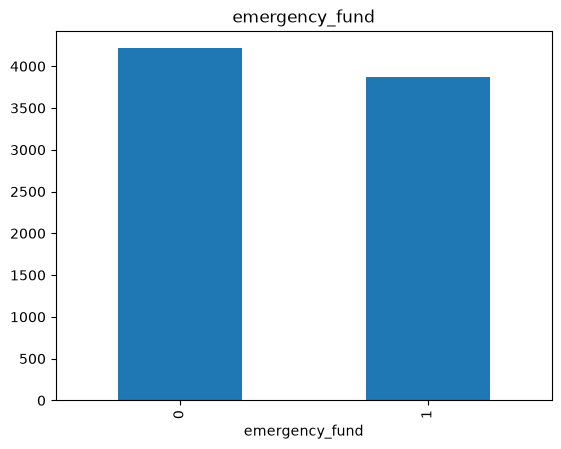

In [106]:
for feature in feature_nan:
    data = dataset.copy()
    
    data[feature] = np.where(data[feature].isnull(), 1, 0)
    

    data.groupby(feature)['max_monthly_emi'].median().plot.bar()
    plt.title(feature)
    plt.show()

### Here With  the relation between the missing values and the dependent variable is clearly visible.So We need to replace these nan values with something meaningful which we will do in the Feature Engineering section

In [107]:
numerical_features=[feature for feature in dataset.columns if dataset[feature].dtype !='str']

In [108]:
len(numerical_features)

18

In [109]:
categorical_features=[feature for feature in dataset.columns if dataset[feature].dtype =='str']

In [110]:
len(categorical_features)

9

In [111]:
dataset[categorical_features].dtypes

gender             str
marital_status     str
education          str
employment_type    str
company_type       str
house_type         str
existing_loans     str
emi_scenario       str
emi_eligibility    str
dtype: object

In [112]:
dataset[numerical_features].dtypes

age                         Int64
monthly_salary            float64
years_of_employment       float64
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
current_emi_amount        float64
credit_score              float64
bank_balance              float64
emergency_fund            float64
requested_amount          float64
requested_tenure            int64
max_monthly_emi           float64
dtype: object

## Duplicated check

In [113]:
dataset.duplicated().sum()

np.int64(0)

## NO duplicated value is present in the dataset

In [114]:
discrete_feature=[feature for feature in numerical_features if len(dataset[feature].unique())<25]
print("Discrete Variables Count: {}".format(len(discrete_feature)))

Discrete Variables Count: 3


In [115]:
dataset[discrete_feature]

,age,family_size,dependents
0,38,3,2
1,38,2,1
2,38,4,3
3,58,5,4
4,48,4,3
...,...,...,...
404795,27,4,3
404796,38,5,4
404797,32,1,0
404798,48,4,3


In [116]:
continuous_features=[feature for feature in numerical_features if feature not in discrete_feature]
print("continuous Variables Count: {}".format(len(continuous_features)))

continuous Variables Count: 15


In [82]:
dataset[continuous_features].head()

,monthly_salary,years_of_employment,monthly_rent,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
0,82600.0,0.9,20000.0,0.0,0.0,7200.0,19500.0,13200.0,23700.0,660.0,70200.0,850000.0,15,500.0
1,21500.0,7.0,0.0,5100.0,0.0,1400.0,5400.0,3500.0,4100.0,714.0,26900.0,128000.0,19,700.0
2,86100.0,5.8,0.0,0.0,0.0,10200.0,19400.0,6000.0,0.0,650.0,324200.0,306000.0,16,27775.0
3,66800.0,2.2,0.0,11400.0,0.0,6200.0,11900.0,7900.0,0.0,685.0,178100.0,304000.0,83,16170.0
4,57300.0,3.4,0.0,9400.0,21300.0,3600.0,16200.0,8100.0,0.0,770.0,28200.0,252000.0,7,500.0


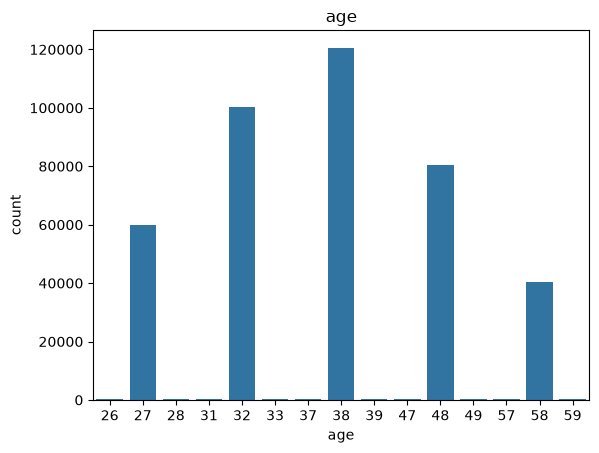

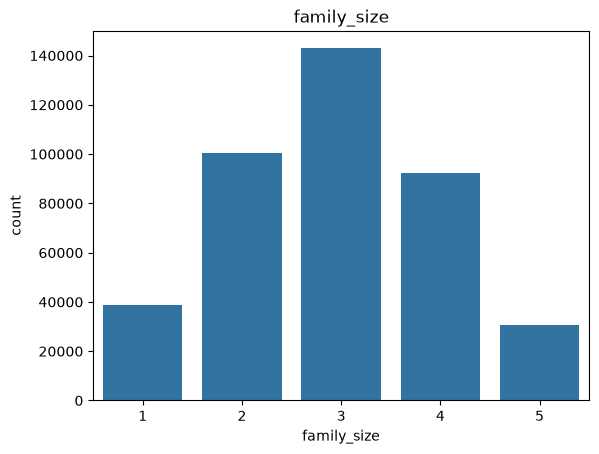

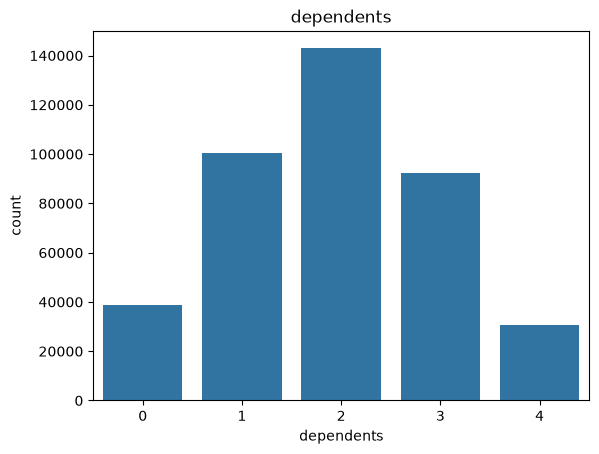

In [86]:
for feature in discrete_feature:
    sns.countplot(x=feature, data=dataset)
    plt.title(feature)
    plt.show()

#### Discrete Feature Observation: The age distribution is concentrated around a few age groups, with age 38 being the most frequent. Family size is mainly concentrated around 2–4 members, with 3 being the most common. Similarly, the number of dependents is mainly concentrated around 1–3, with 2 being the most common. Additionally, family size and dependents appear to have a deterministic relationship, which should be checked because it may introduce redundant information

In [90]:
(dataset["family_size"] - 1 == dataset["dependents"]).all()

np.True_

##### Family size and dependents have a perfect deterministic relationship, where dependents = family size − 1 for every observation. Therefore, these two features contain redundant information, and one of them can be removed during feature selection/feature engineering to avoid unnecessary duplication.

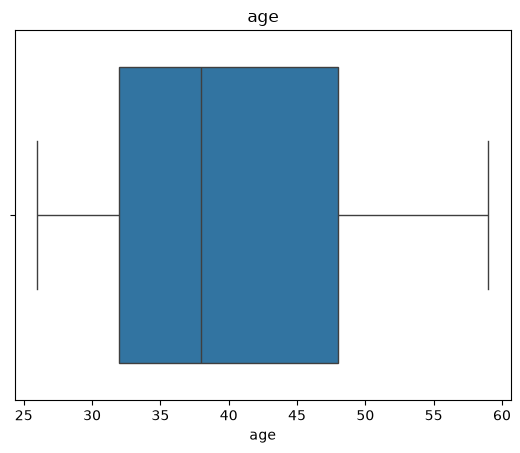

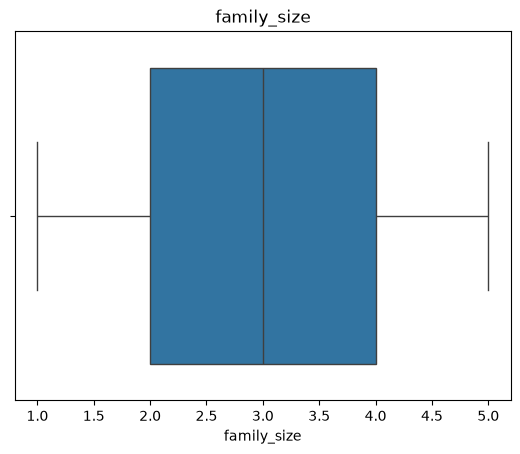

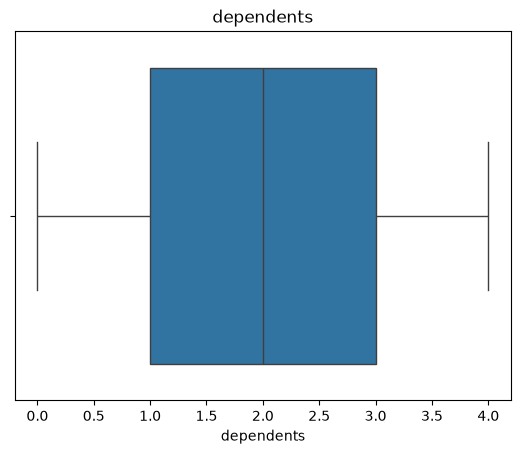

In [91]:
for feature in discrete_feature:
    sns.boxplot(x=feature, data=dataset)
    plt.title(feature)
    plt.show()

#### No Outliers is present in discrete features

## Univariate analysis for continuous features

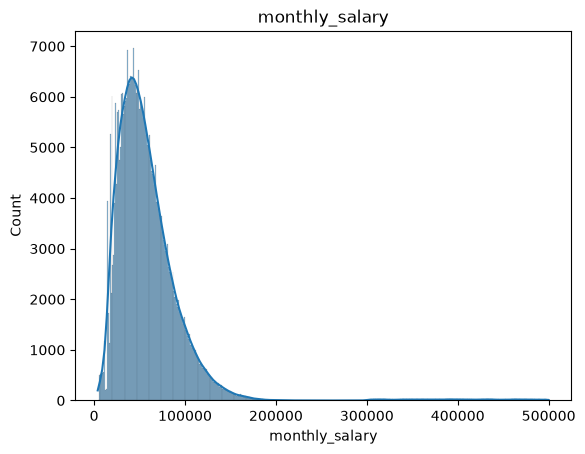

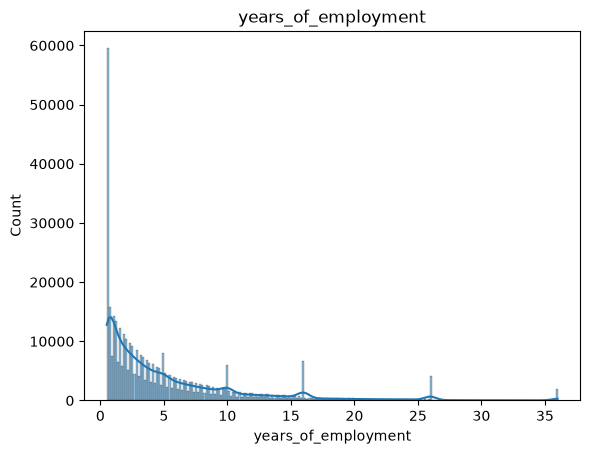

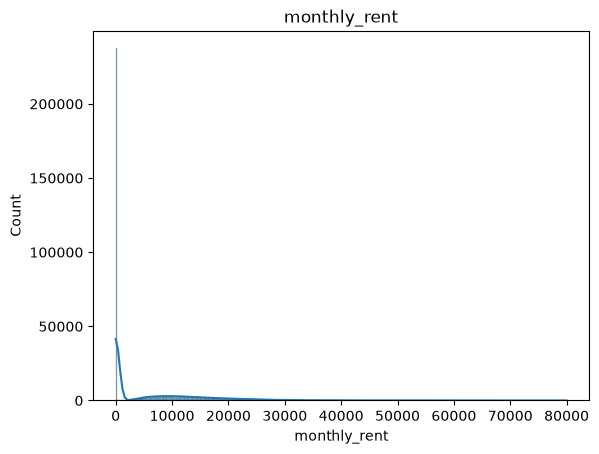

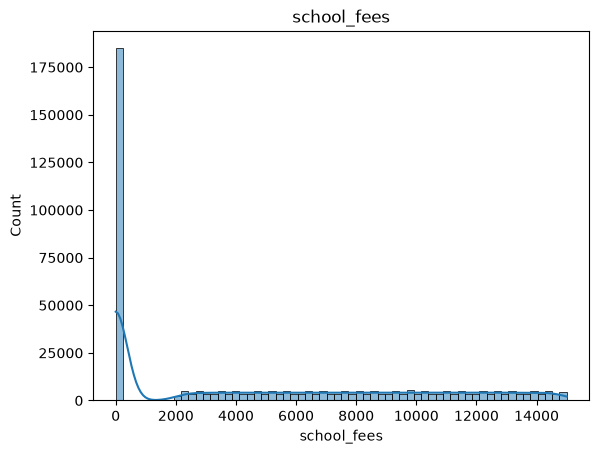

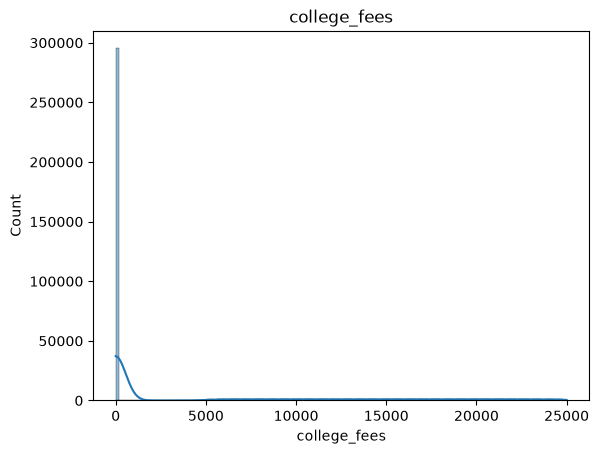

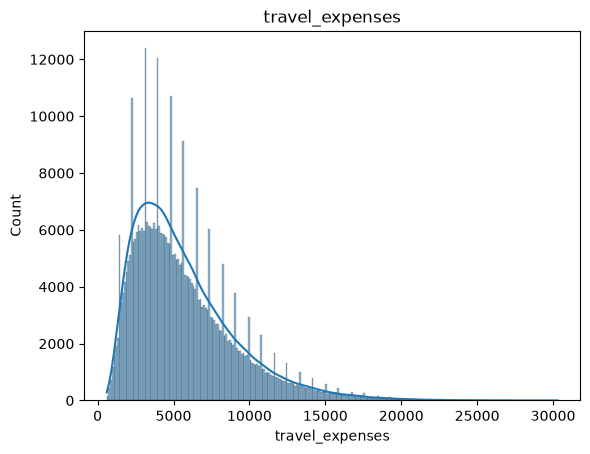

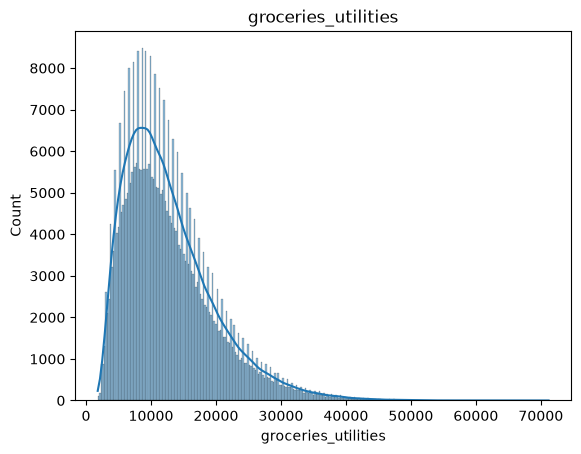

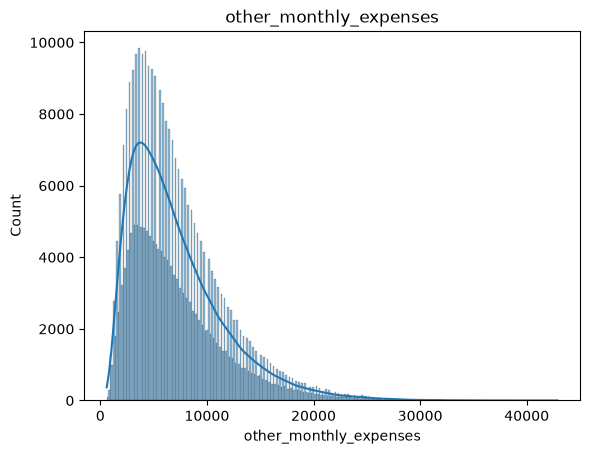

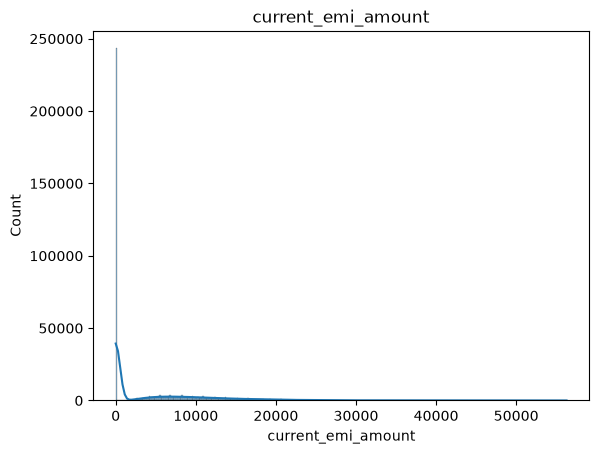

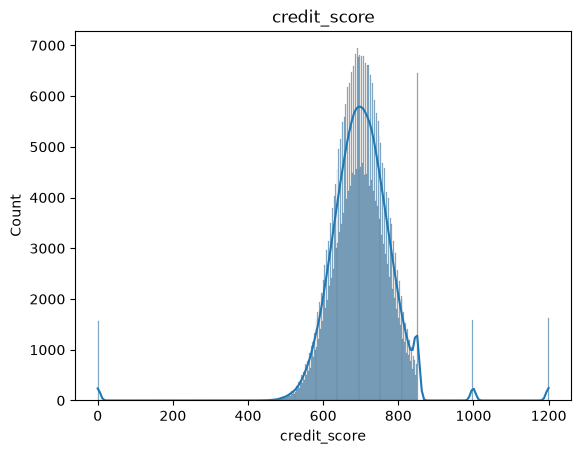

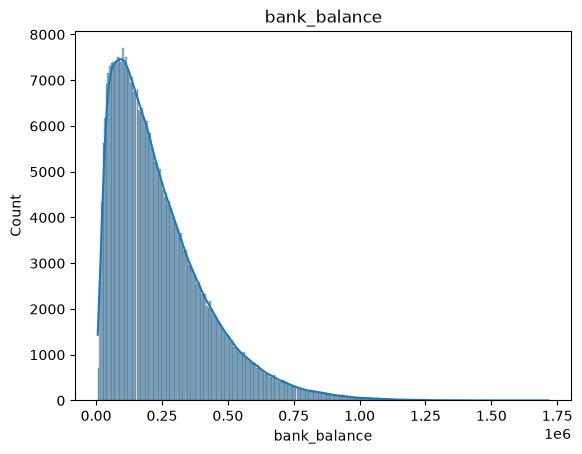

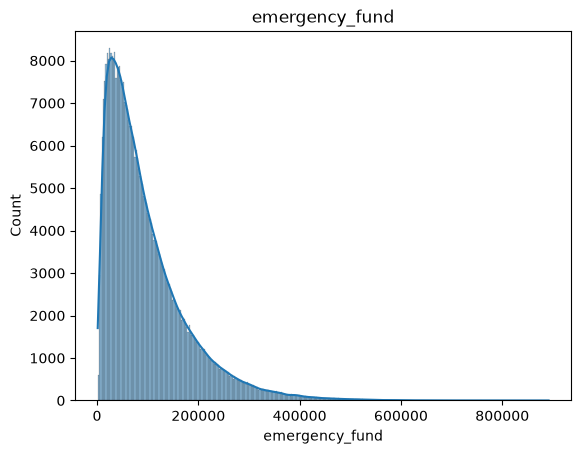

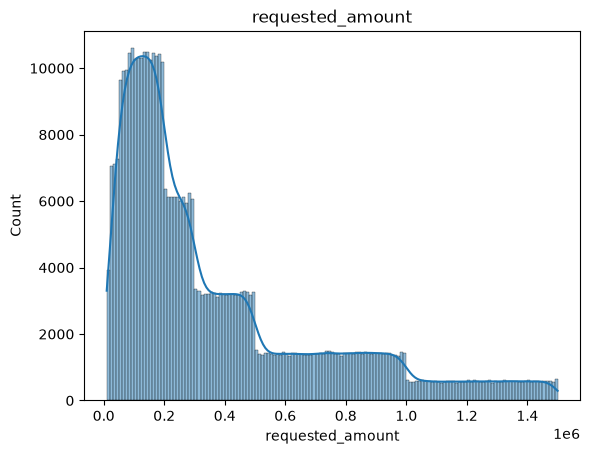

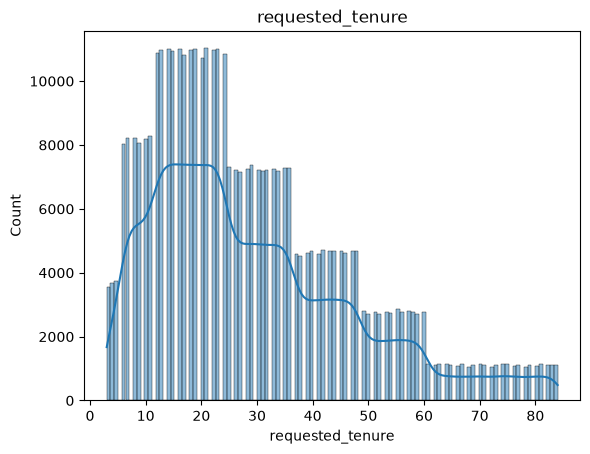

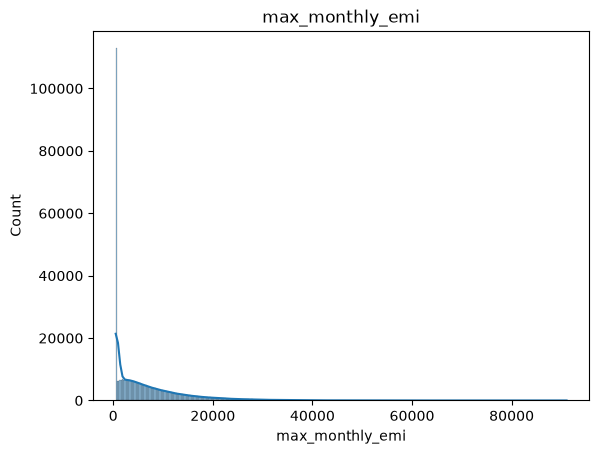

In [117]:
for feature in continuous_features:
    sns.histplot(dataset[feature], kde=True)
    plt.title(feature)
    plt.show()

In [118]:
for feature in continuous_features:
    print(feature, ":", dataset[feature].skew())

monthly_salary : 4.833036897501728
years_of_employment : 2.1479704585519444
monthly_rent : 1.6123843959223387
school_fees : 0.5843446764078953
college_fees : 1.5399824282976142
travel_expenses : 1.3559369251378237
groceries_utilities : 1.2289676223747947
other_monthly_expenses : 1.4049944944465216
current_emi_amount : 1.777650067313552
credit_score : -1.0940635046891765
bank_balance : 1.414799885310764
emergency_fund : 1.7899995023706674
requested_amount : 1.3861453213995707
requested_tenure : 0.9186795002030428
max_monthly_emi : 1.9741590612751134


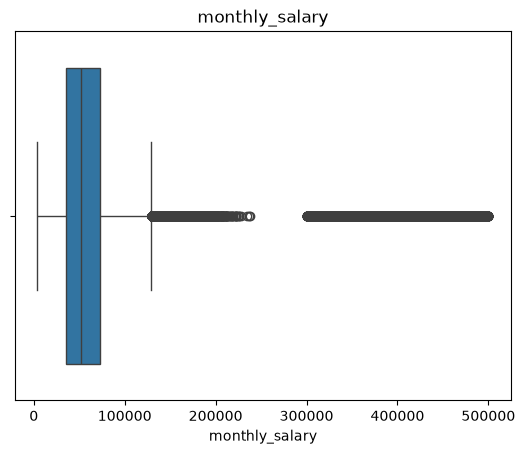

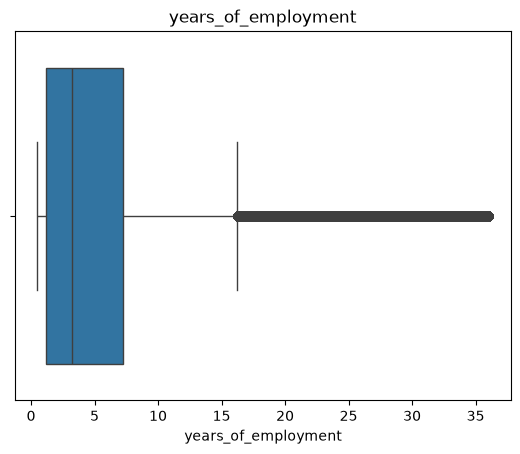

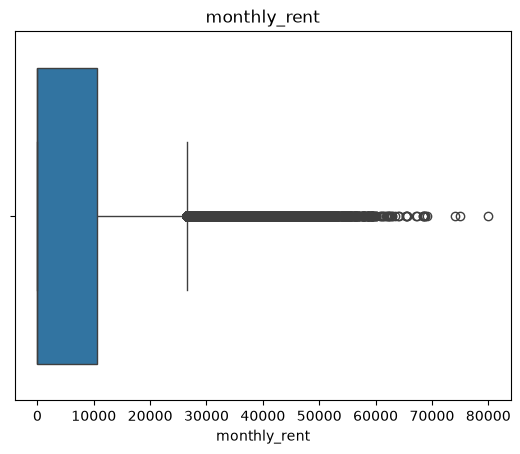

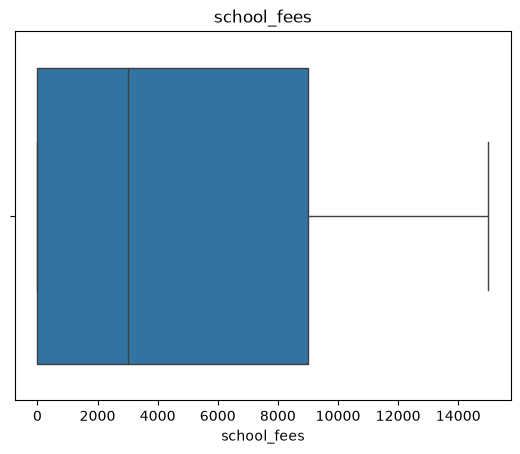

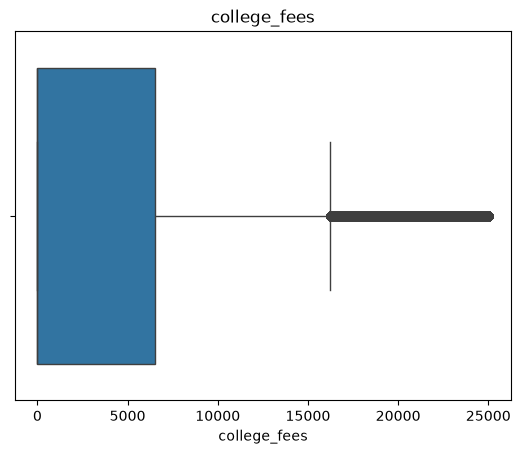

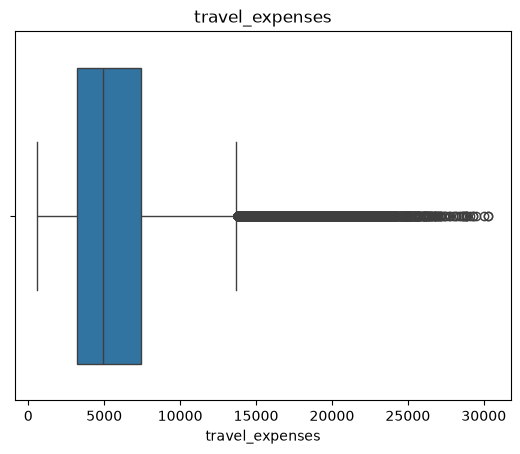

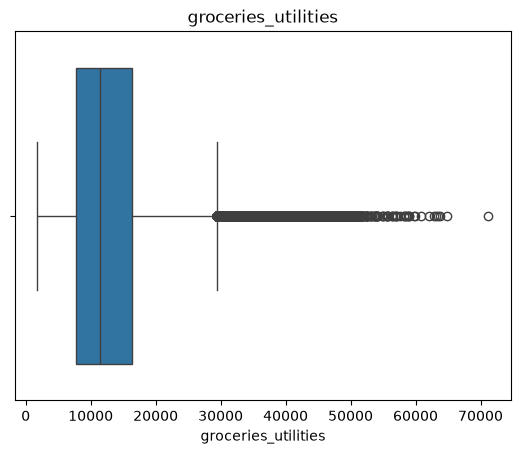

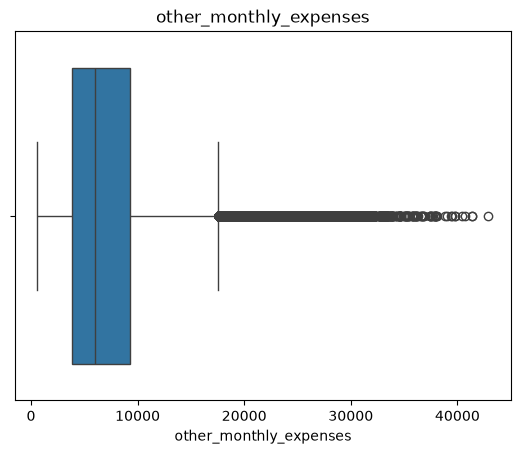

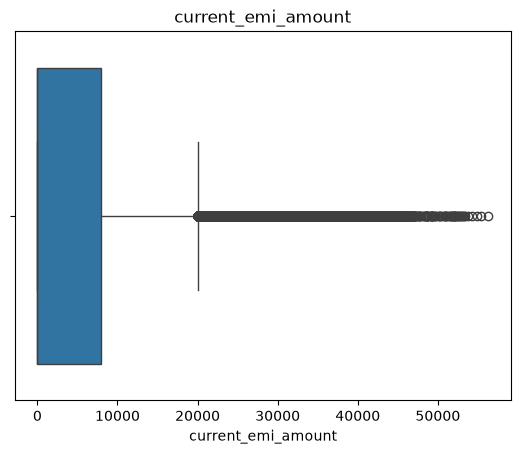

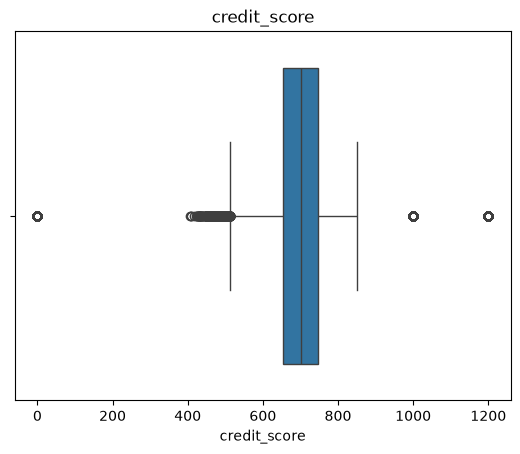

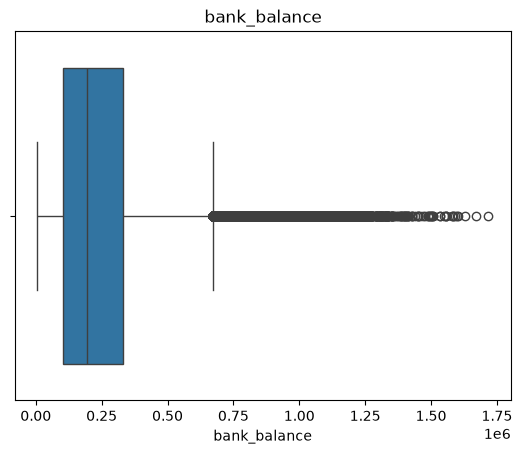

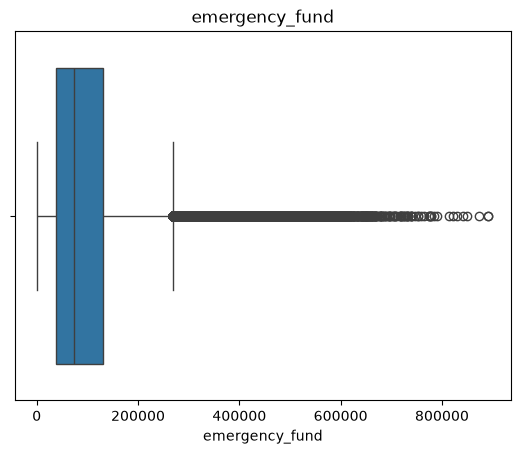

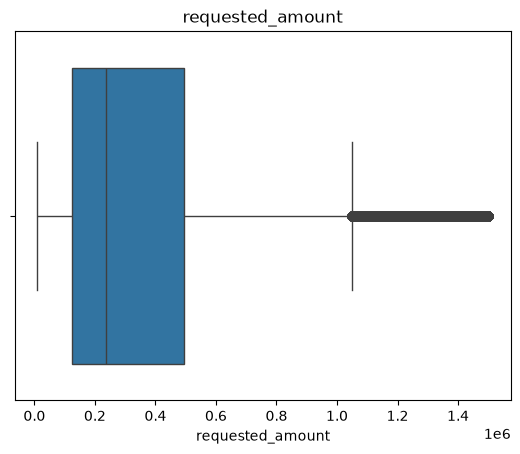

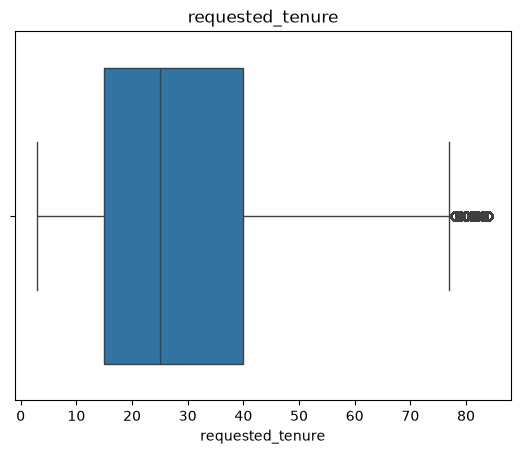

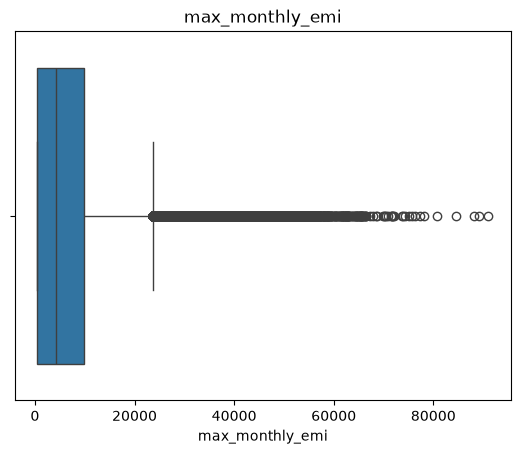

In [ ]:
for feature in continuous_features:
    sns.boxplot(x=dataset[feature])
    plt.title(feature)
    plt.show()

##### Most of the continuous features are positively skewed and contain outliers, indicating the presence of some unusually high values. monthly_salary shows the highest positive skewness (4.83), followed by years_of_employment (2.15)  suggesting a strong right-tailed distribution with potential extreme values. monthly_rent, college_fees, travel_expenses, groceries_utilities, other_monthly_expenses, current_emi_amount, emergency_fund, requested_amount, bank_balance and requested_tenure are also positively skewed and show outliers. credit_score is negatively skewed (-1.09), indicating a longer left tail and the presence of lower-end outliers. school_fees is moderately positively skewed (0.58) but does not show any apparent outliers. Overall, the continuous features exhibit varying degrees of skewness, with outliers present in most features, which should be considered during feature engineering and preprocessing.

In [120]:
for feature in categorical_features:
    print(f"\n{feature}")
    print(dataset[feature].value_counts())


gender
gender
Male      242950
Female    161850
Name: count, dtype: int64

marital_status
marital_status
Married    307837
Single      96963
Name: count, dtype: int64

education
education
Graduate         181015
Post Graduate    100314
High School       60732
Professional      60335
Name: count, dtype: int64

employment_type
employment_type
Private          283099
Government        81167
Self-employed     40534
Name: count, dtype: int64

company_type
company_type
Large Indian    121139
MNC             101409
Mid-size        101301
Startup          60706
Small            20245
Name: count, dtype: int64

house_type
house_type
Rented    161601
Own       142307
Family    100892
Name: count, dtype: int64

existing_loans
existing_loans
No     243227
Yes    161573
Name: count, dtype: int64

emi_scenario
emi_scenario
Home Appliances EMI        80988
Personal Loan EMI          80980
E-commerce Shopping EMI    80948
Education EMI              80942
Vehicle EMI                80942
Name: count, 

#### The categorical features show varying levels of category distribution. Gender, marital status, employment type, house type, and existing loans have noticeable differences in category frequencies, while EMI scenarios are almost equally distributed. The target variable emi_eligibility is highly imbalanced, with Not_Eligible representing the majority of observations and High_Risk representing a much smaller proportion. This class imbalance should be considered during model training and evaluation.

# Bivariate analysis

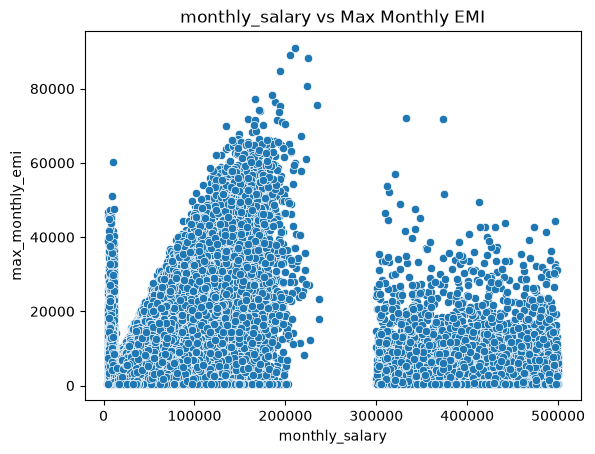

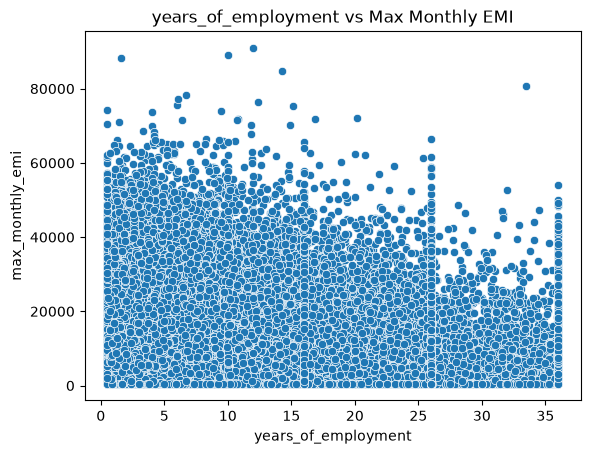

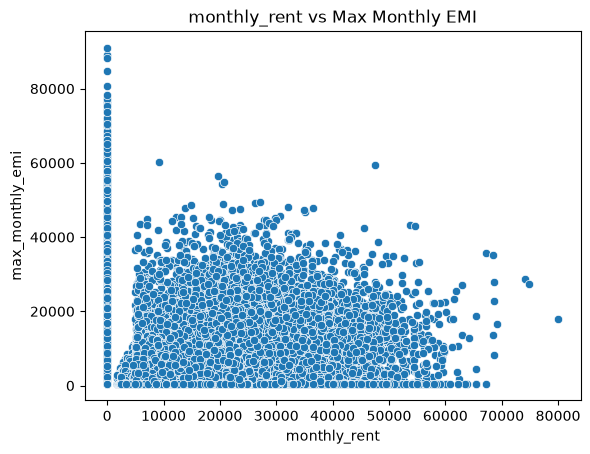

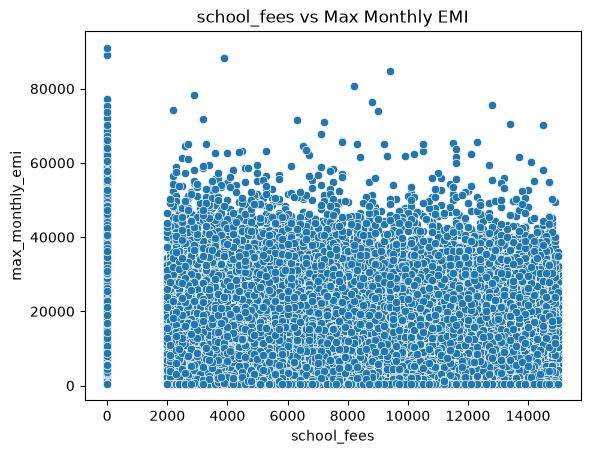

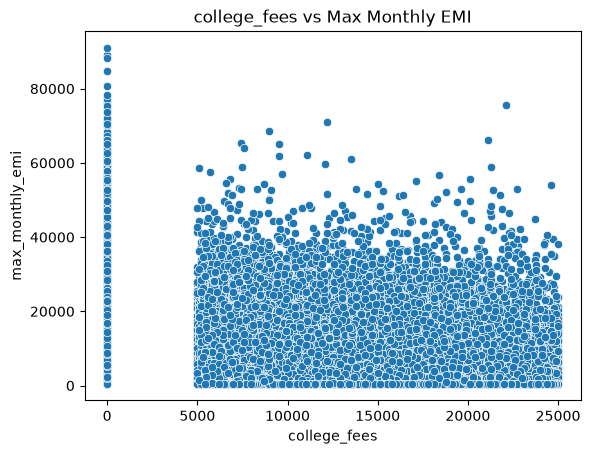

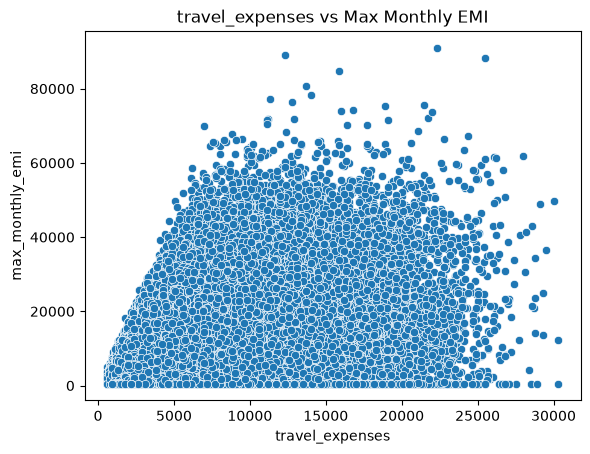

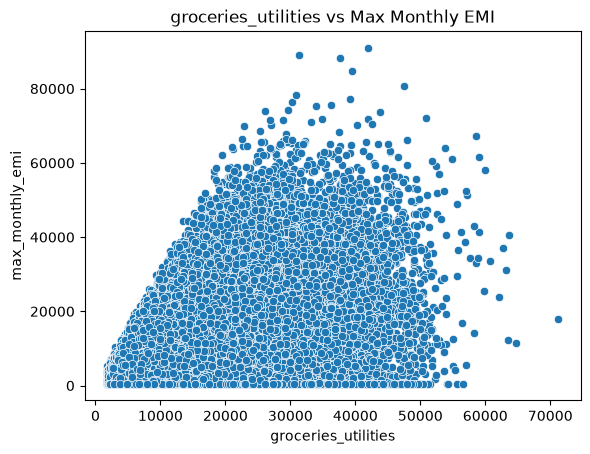

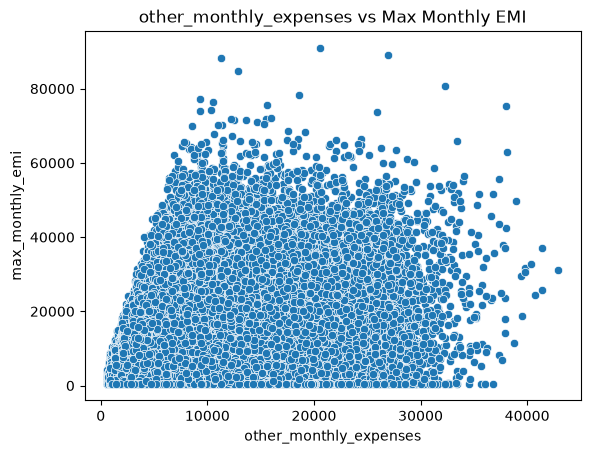

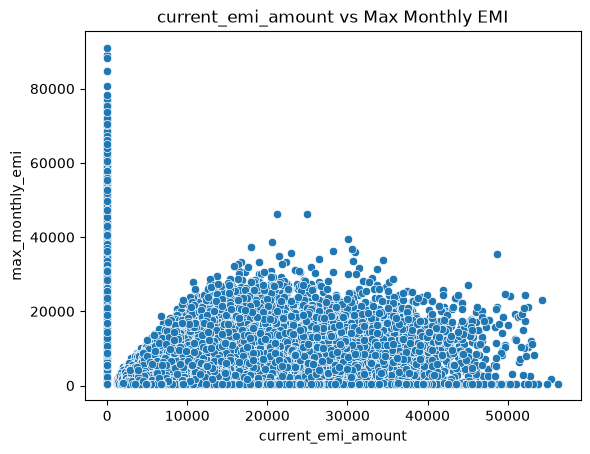

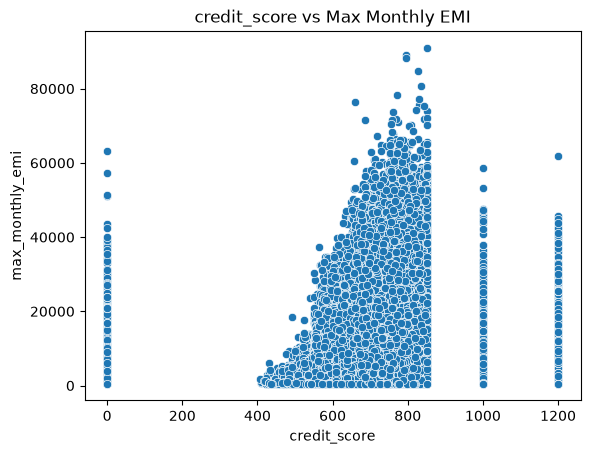

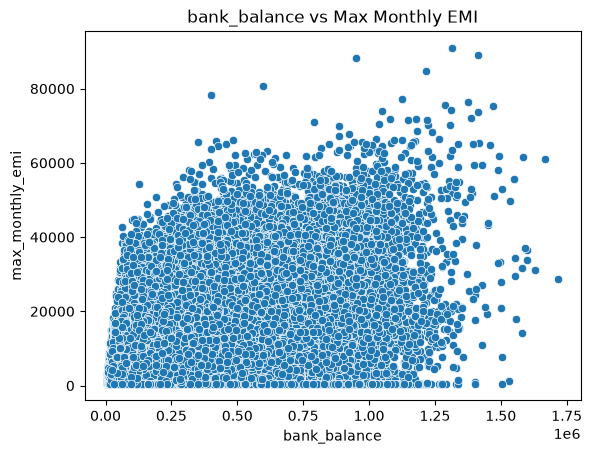

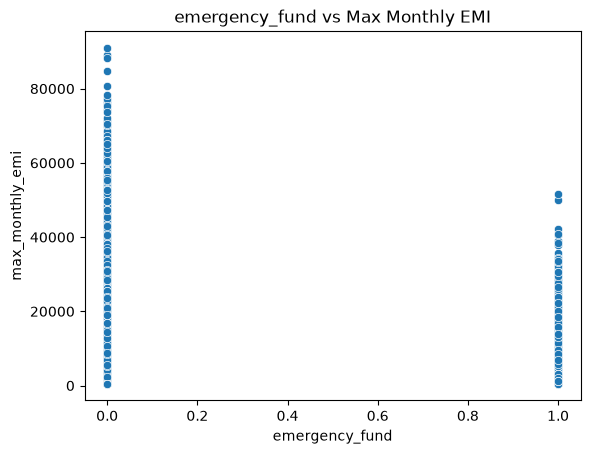

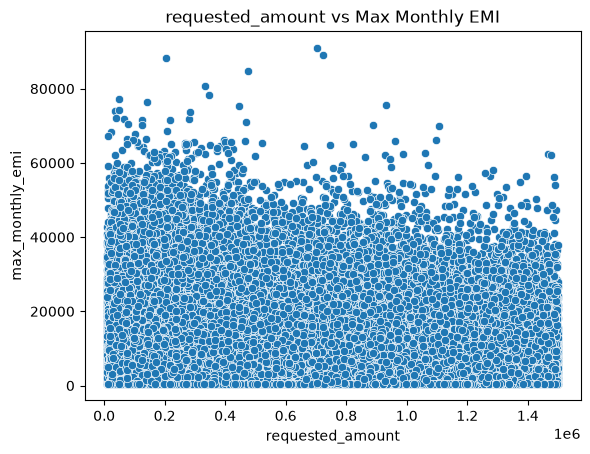

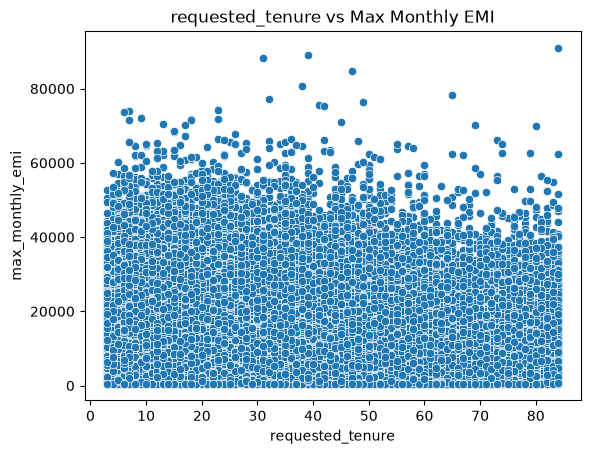

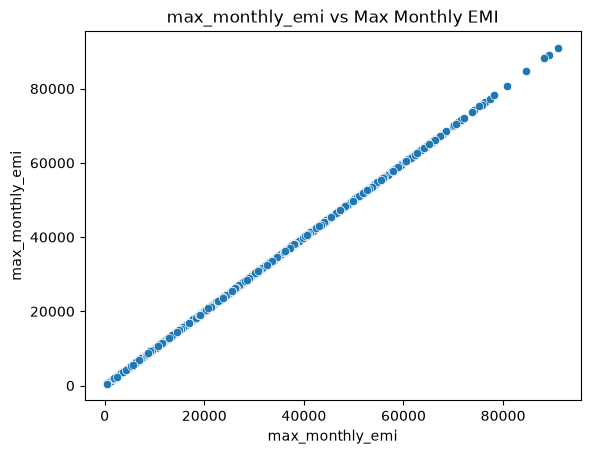

In [121]:
for feature in continuous_features:
    sns.scatterplot(
        data=dataset,
        x=data[feature],
        y="max_monthly_emi"
    )
    plt.title(f"{feature} vs Max Monthly EMI")
    plt.show()

In [123]:
correlation_results = {}

for feature in continuous_features:
    correlation_results[feature] = dataset[feature].corr(
        dataset["max_monthly_emi"]
    )

correlation_results = dict(
    sorted(
        correlation_results.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

for feature, correlation in correlation_results.items():
    print(f"{feature}: {correlation:.4f}")

max_monthly_emi: 1.0000
groceries_utilities: 0.4847
bank_balance: 0.4586
travel_expenses: 0.4409
emergency_fund: 0.4152
other_monthly_expenses: 0.3821
monthly_salary: 0.3792
credit_score: 0.2294
years_of_employment: 0.0289
requested_tenure: 0.0010
requested_amount: -0.0020
monthly_rent: -0.1701
school_fees: -0.2152
current_emi_amount: -0.2424
college_fees: -0.2588


##### The correlation analysis shows that groceries_utilities, bank_balance, travel_expenses, emergency_fund, and monthly_salary have moderate positive relationships with max_monthly_emi. credit_score has a weak positive relationship, while years_of_employment, requested_tenure, and requested_amount have negligible linear relationships with the target. Among the negatively correlated features, college_fees, current_emi_amount, and school_fees show relatively stronger negative relationships. However, correlation measures only linear association and should not alone be used to remove features.

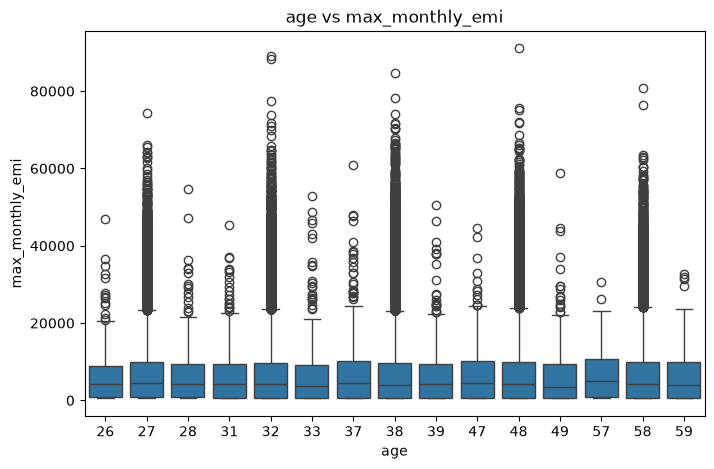

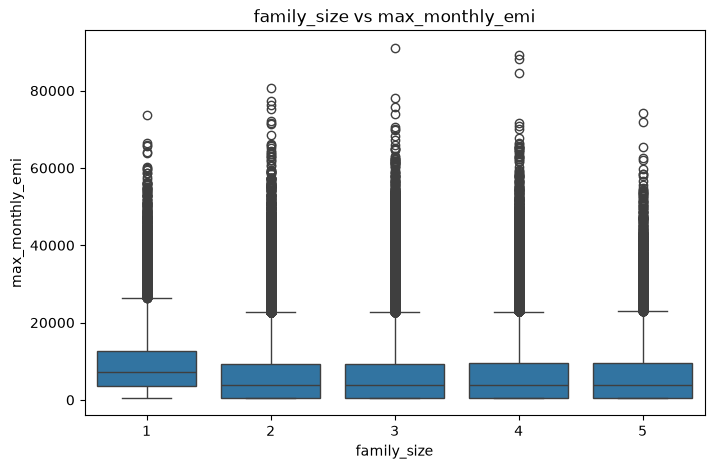

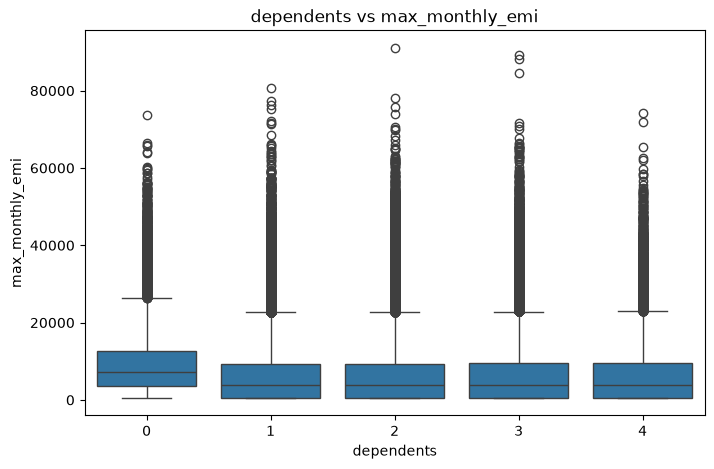

In [124]:
for feature in discrete_feature:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=dataset,
        x=feature,
        y="max_monthly_emi"
    )
    plt.title(f"{feature} vs max_monthly_emi")
    plt.show()

#### The boxplots show that max_monthly_emi has a similar distribution across different values of age, family size, and dependents. There is no clear increasing or decreasing trend in the median max_monthly_emi across these categories. A large number of high-value outliers are present across almost all categories, indicating considerable variation in max_monthly_emi. Overall, these discrete features do not show a strong visible relationship with max_monthly_emi.

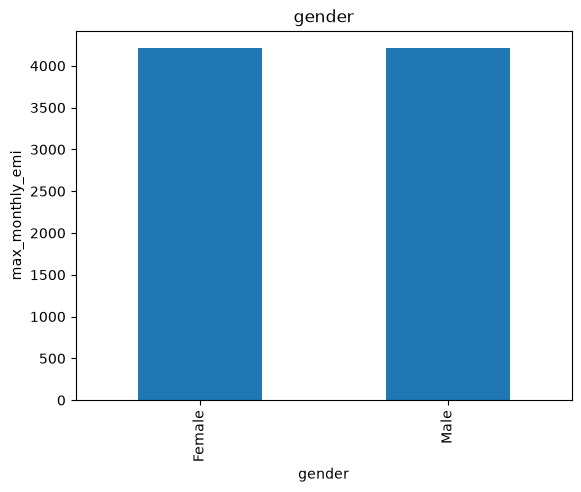

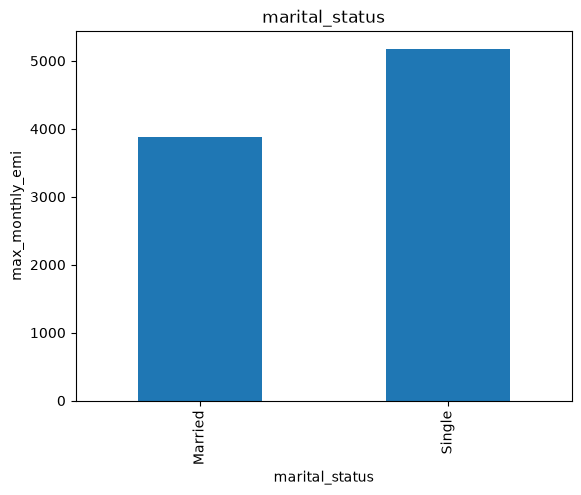

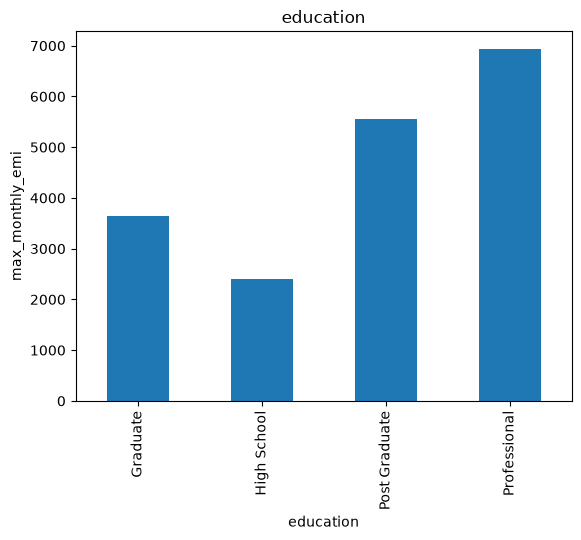

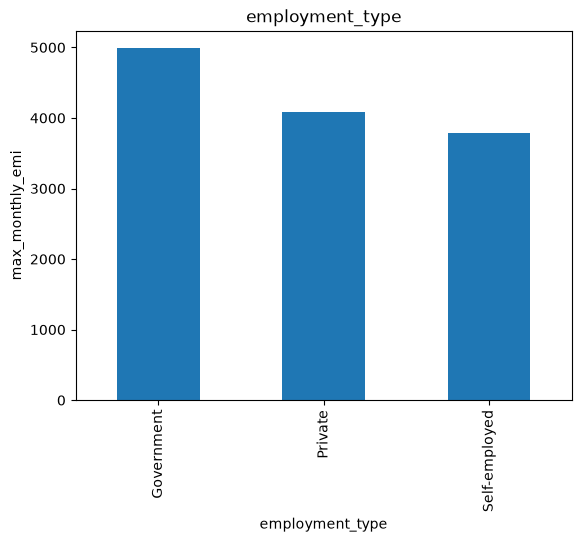

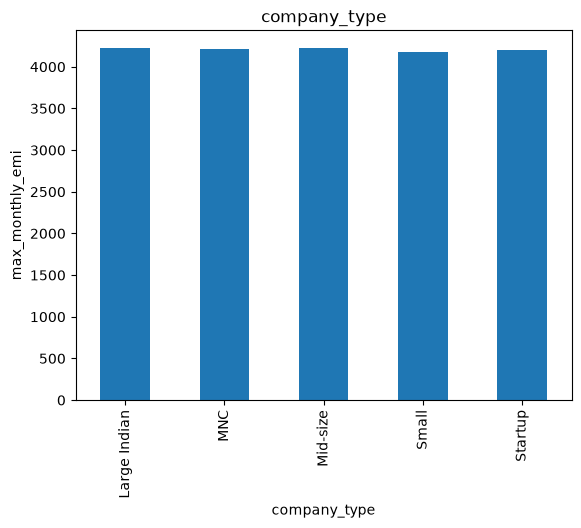

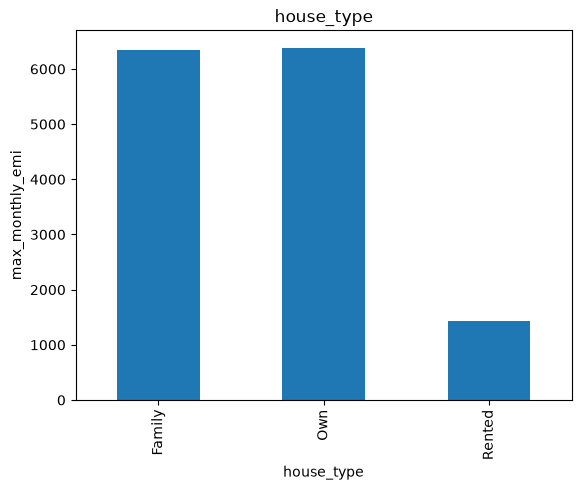

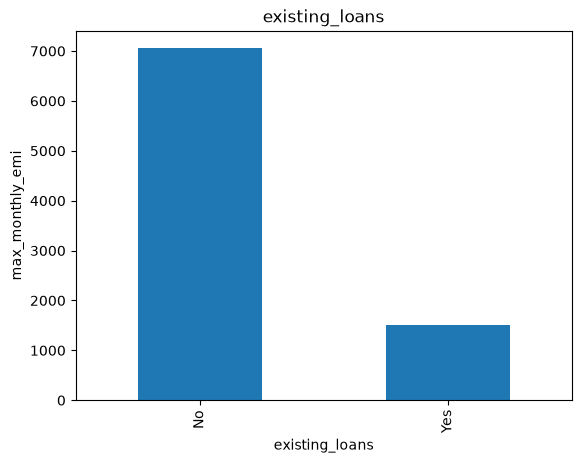

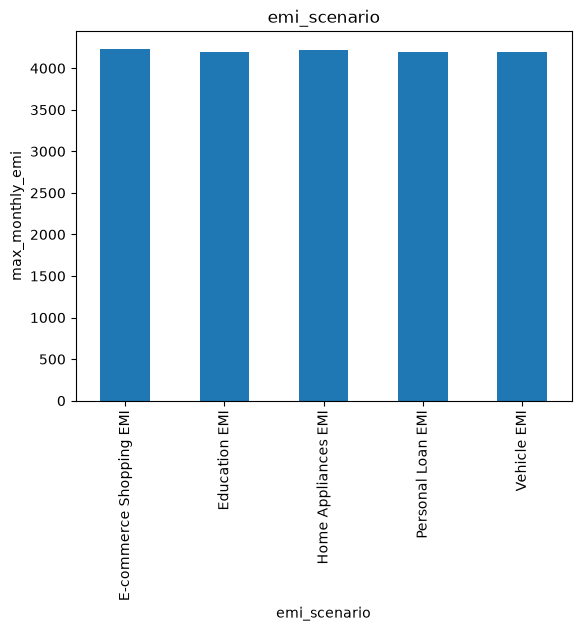

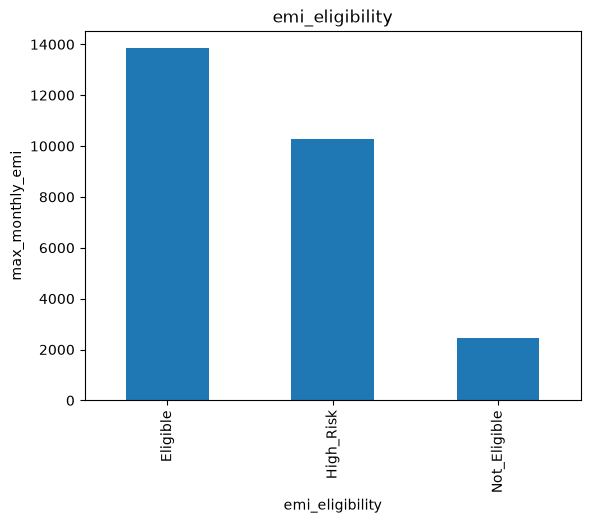

In [126]:
for feature in categorical_features:
    data=dataset.copy()
    data.groupby(feature)['max_monthly_emi'].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel('max_monthly_emi')
    plt.title(feature)
    plt.show()

#### The categorical features show noticeable differences in the average max_monthly_emi across several categories. Gender shows almost no difference between male and female categories. Single individuals have a higher average max_monthly_emi than married individuals. Education shows considerable variation, with Professional and Post Graduate categories having higher average max_monthly_emi, while High School has the lowest. Among employment types, Government employees have the highest average max_monthly_emi, followed by Private and Self-employed individuals. Company type shows relatively similar average max_monthly_emi across its categories. House type shows a substantial difference, with Own and Family categories having much higher average max_monthly_emi than Rented

### Bivariate analysis for classification

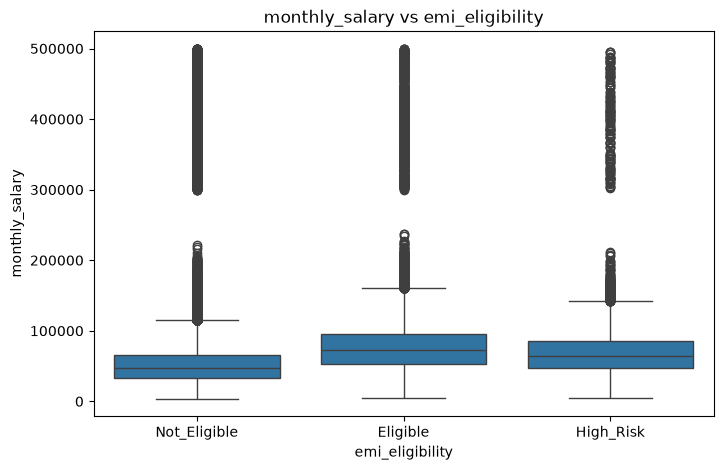

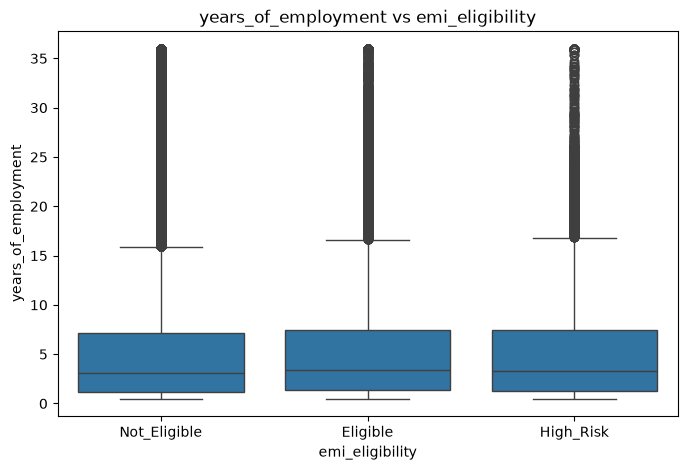

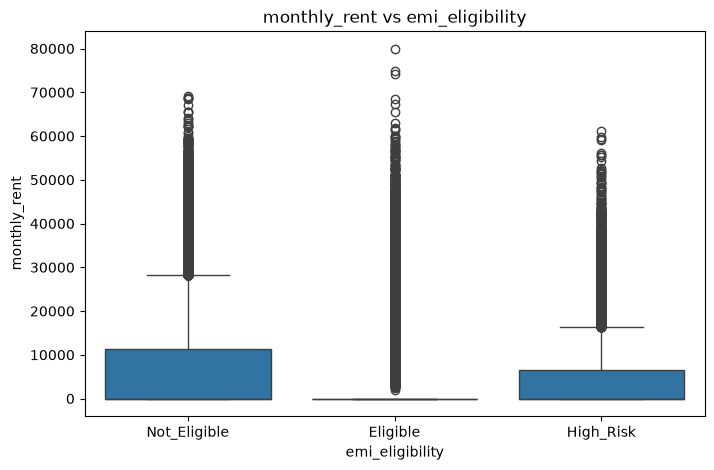

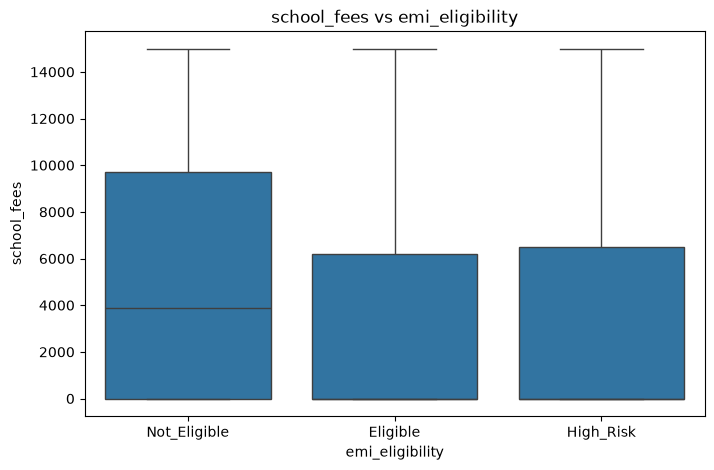

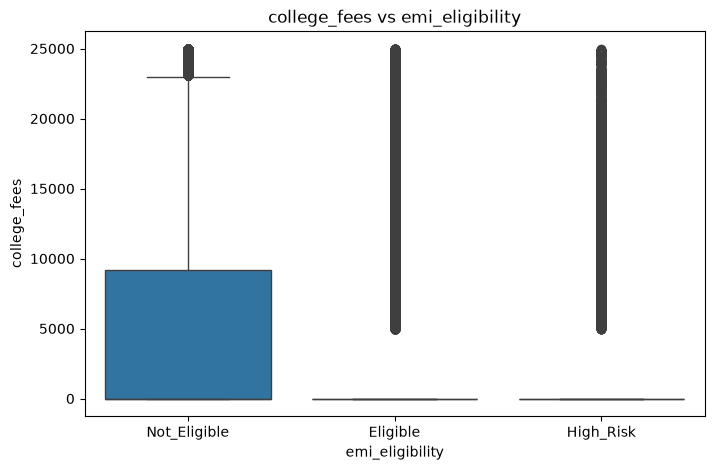

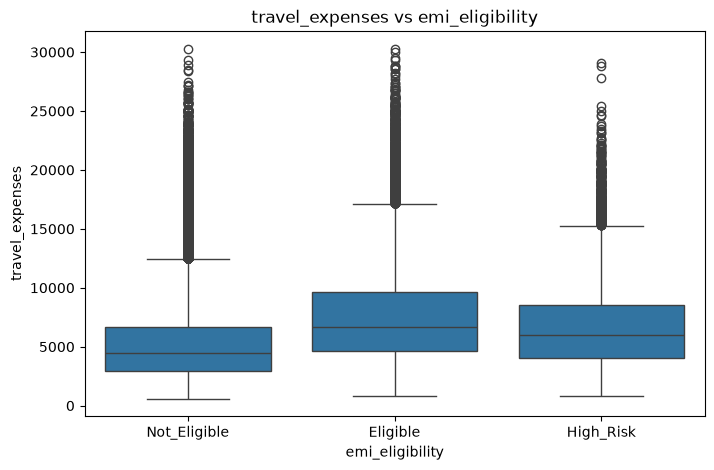

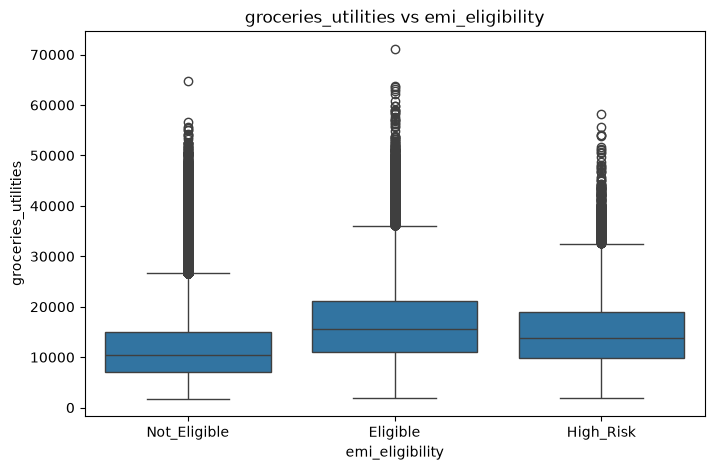

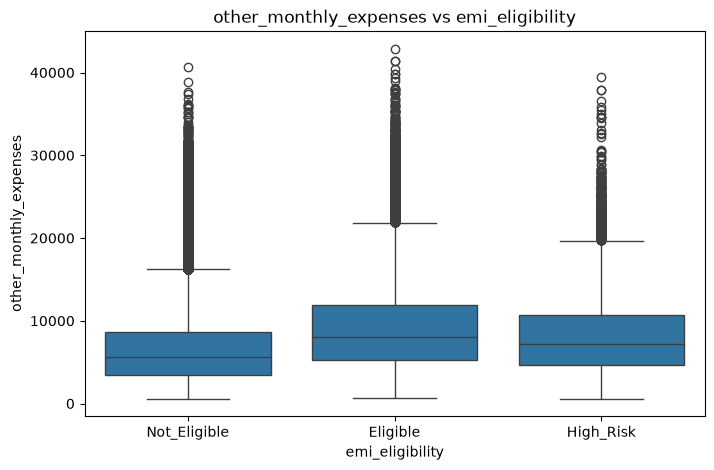

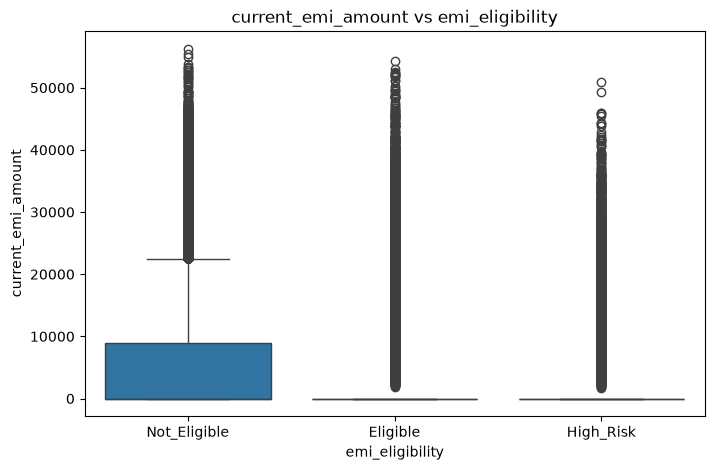

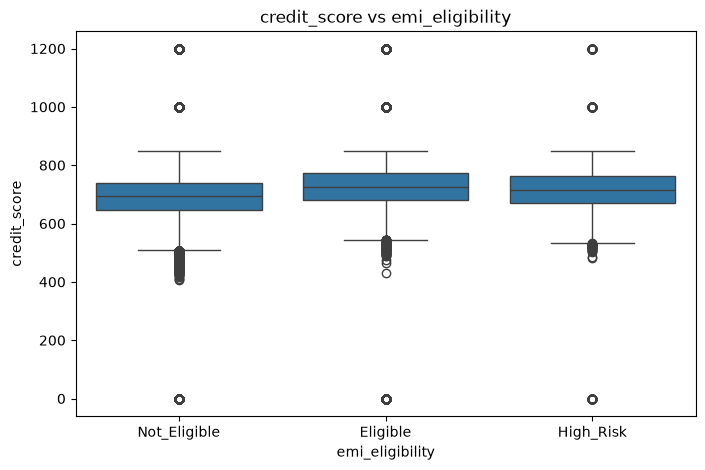

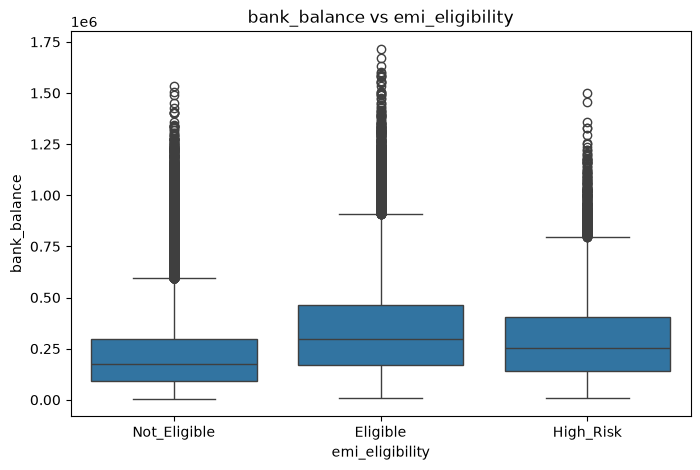

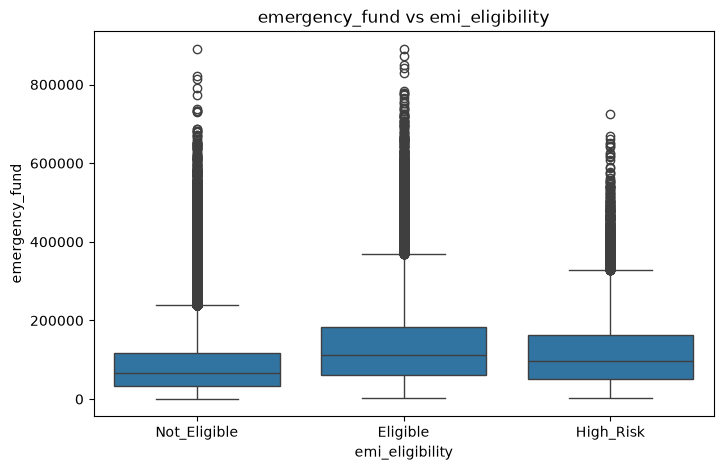

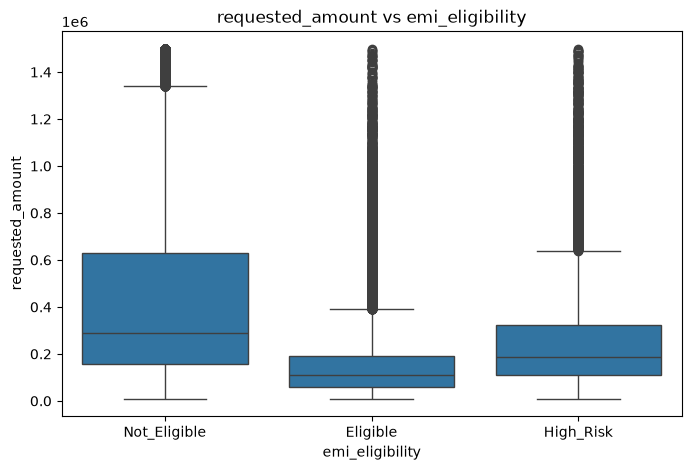

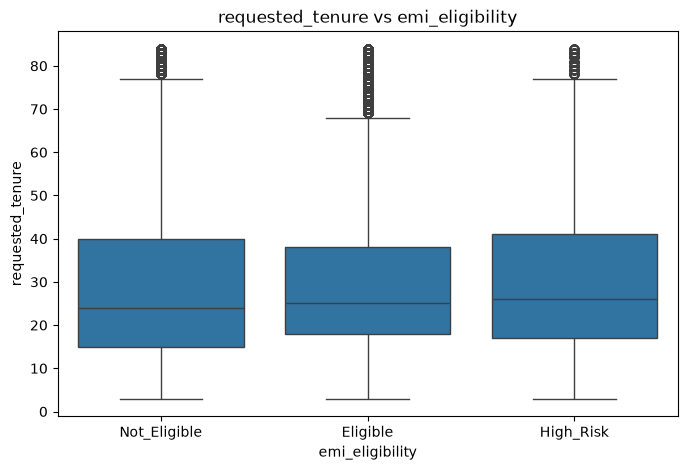

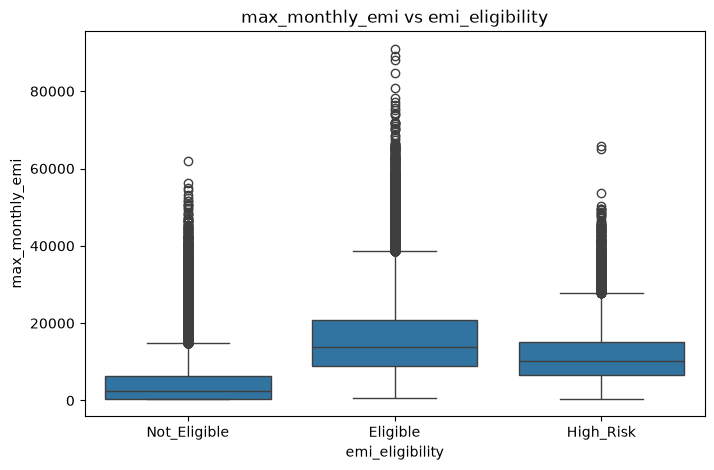

In [127]:
for feature in continuous_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=dataset,
        x="emi_eligibility",
        y=feature
    )
    plt.title(f"{feature} vs emi_eligibility")
    plt.show()

#### Observation: The continuous features show noticeable differences in their distributions across the Not_Eligible, Eligible, and High_Risk classes. monthly_salary, travel_expenses, groceries_utilities, other_monthly_expenses, credit_score, bank_balance, emergency_fund, and max_monthly_emi generally show higher central values for the Eligible class. In contrast, monthly_rent, school_fees, college_fees, current_emi_amount, and requested_amount show higher central values for the Not_Eligible class. years_of_employment shows relatively little separation among the classes. Most continuous features contain several high-value outliers.

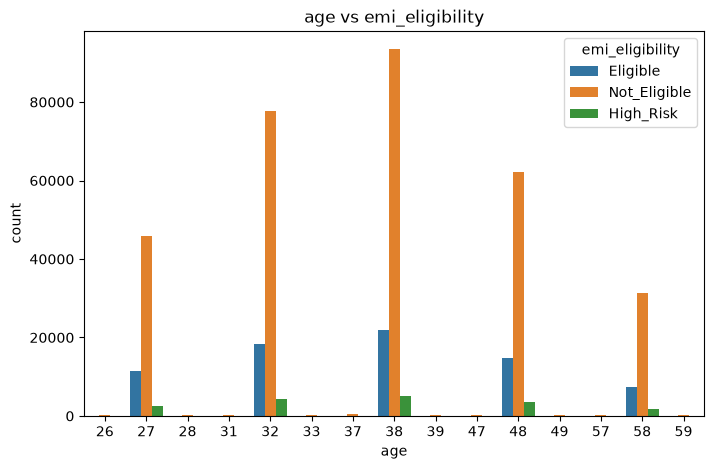

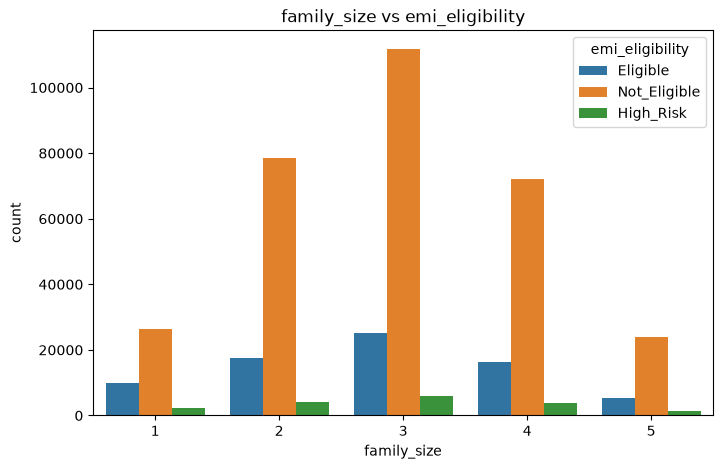

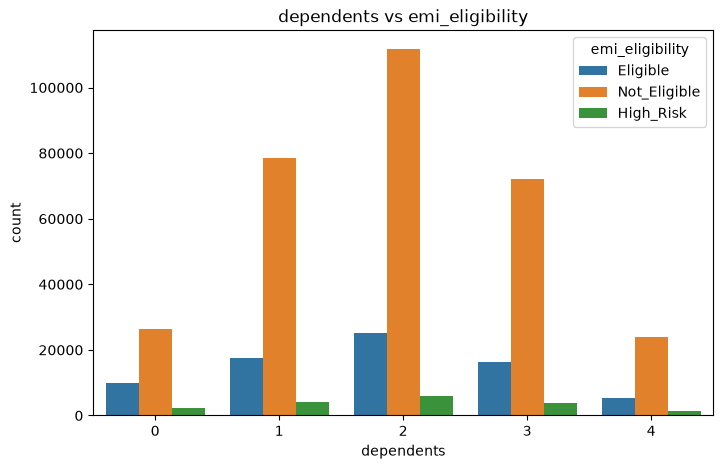

In [128]:
for feature in discrete_feature:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=dataset,
        x=feature,
        hue="emi_eligibility"
    )
    plt.title(f"{feature} vs emi_eligibility")
    plt.show()

#### Observation: The distributions of emi_eligibility vary across the different values of age, family_size, and dependents. However, the raw count plots are strongly influenced by the class imbalance in the target, with Not_Eligible having substantially more observations than the other classes. Therefore, the discrete features should preferably be compared using percentage distributions rather than raw counts to determine whether meaningful differences exist between the eligibility classes.

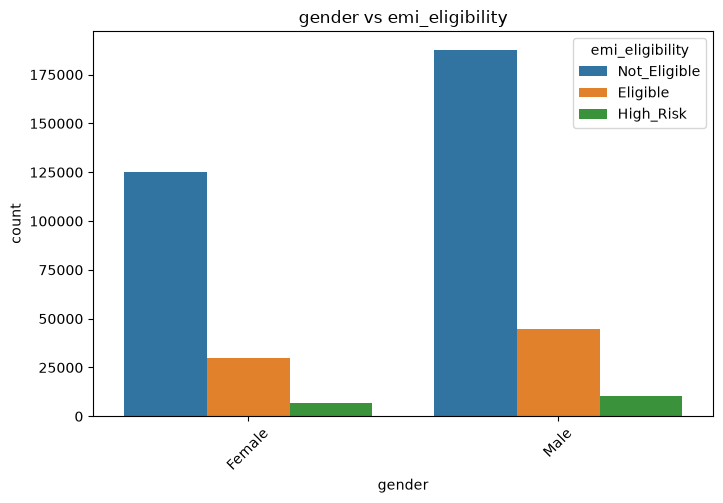

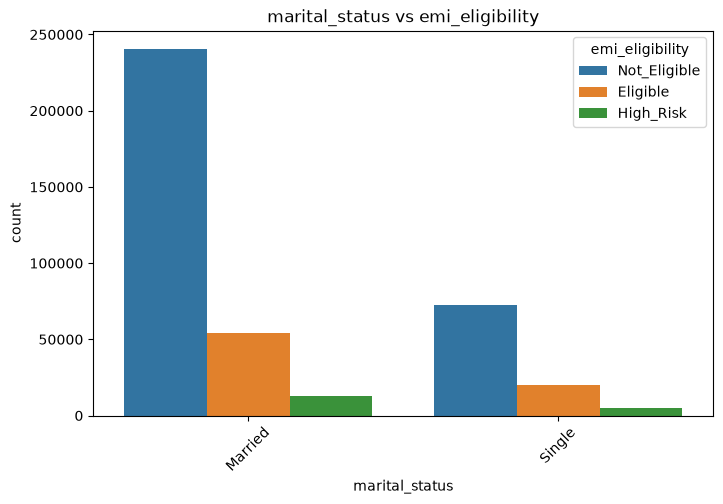

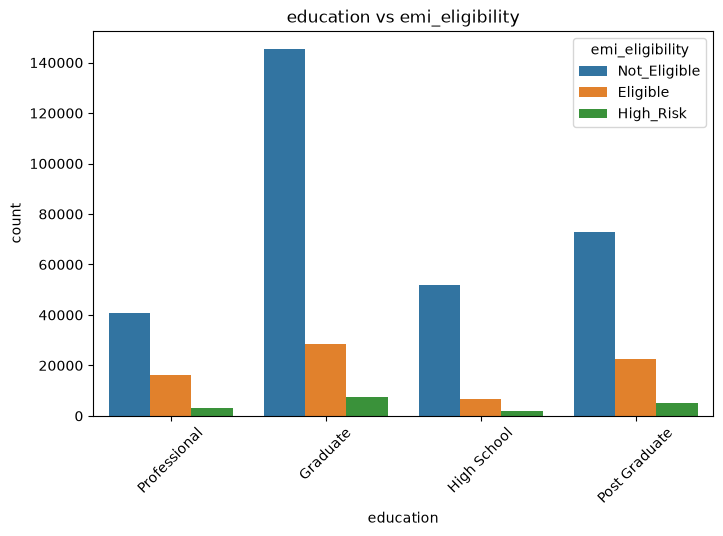

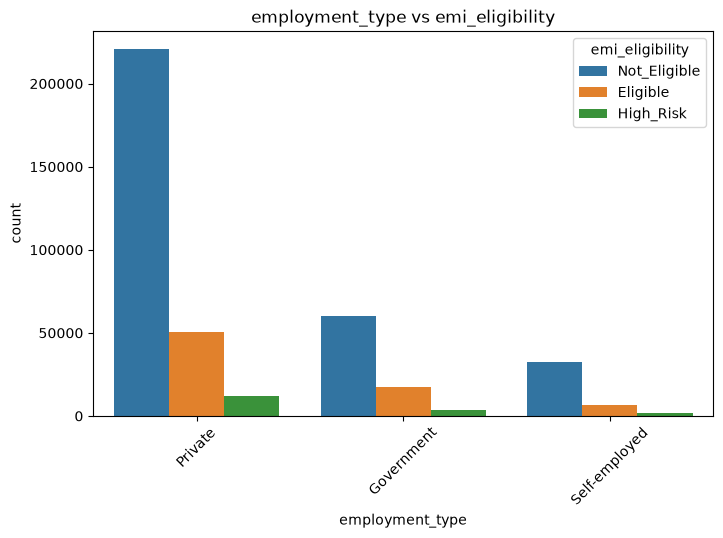

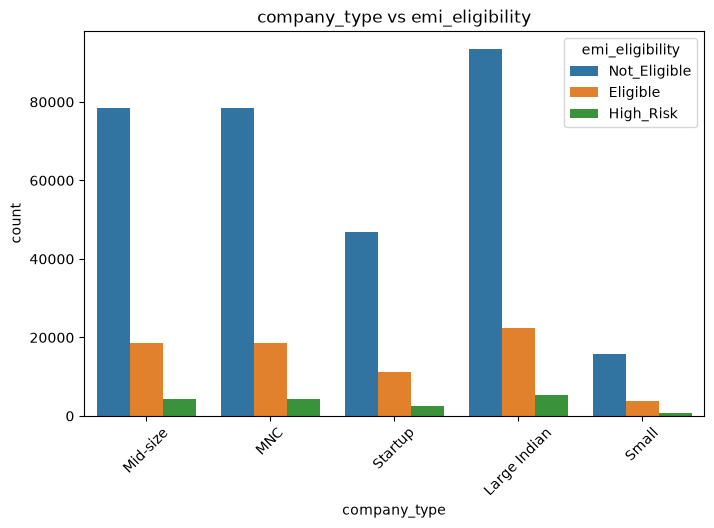

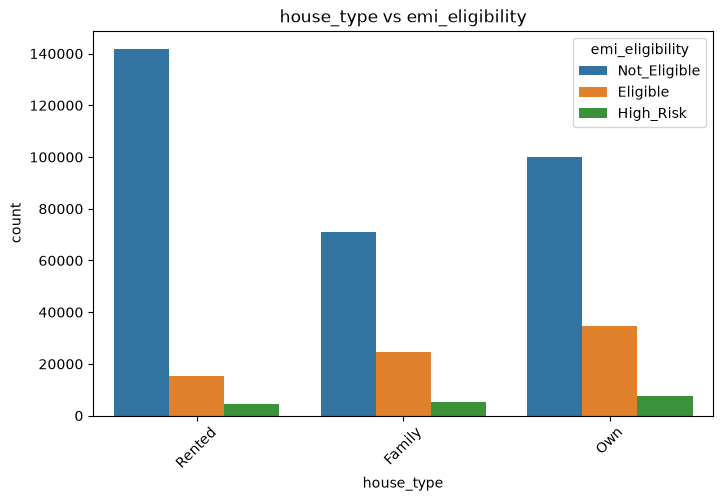

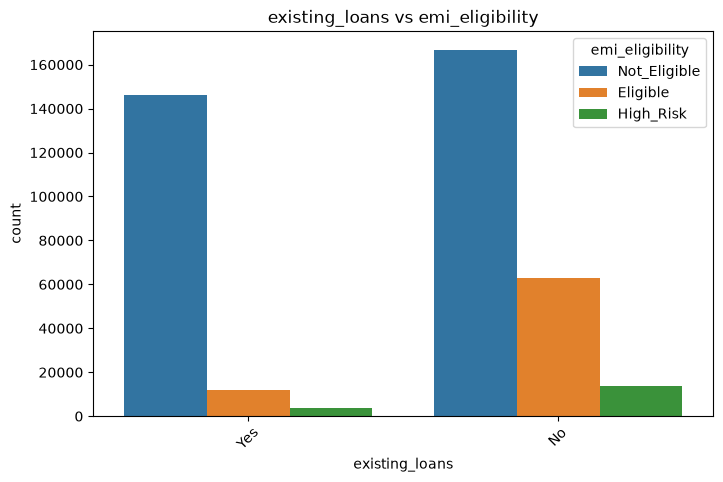

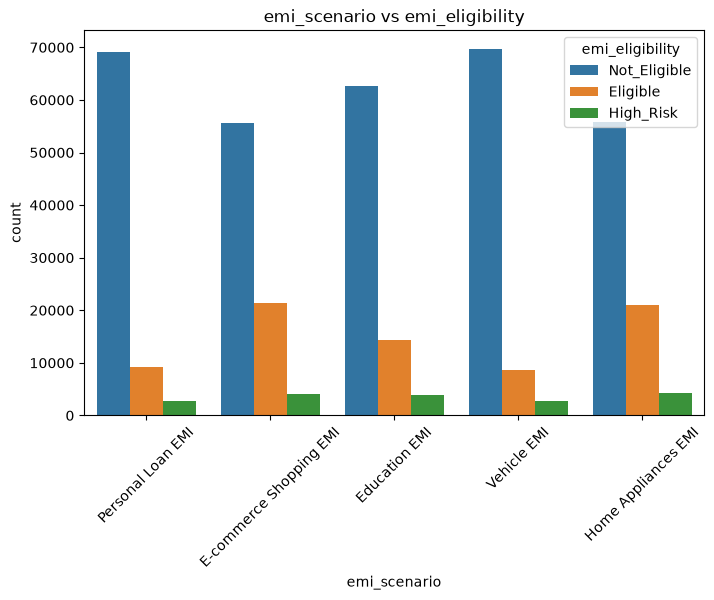

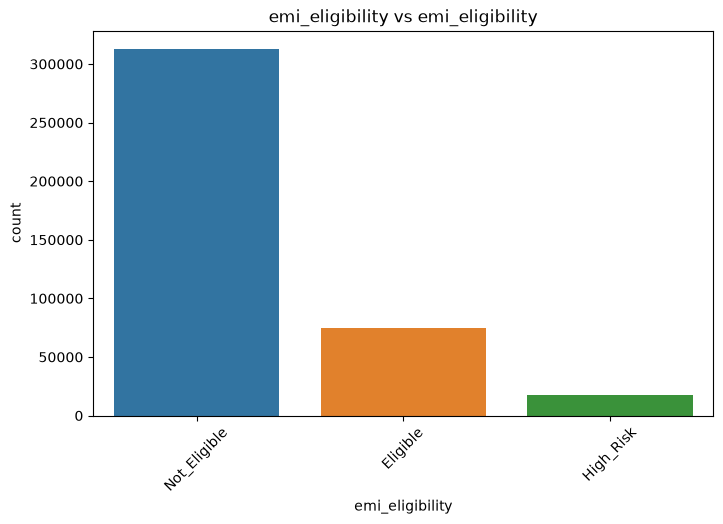

In [129]:
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=dataset,
        x=feature,
        hue="emi_eligibility"
    )
    plt.title(f"{feature} vs emi_eligibility")
    plt.xticks(rotation=45)
    plt.show()

#### Observation: The categorical features show different distributions of EMI eligibility across their respective categories. However, the raw count plots are affected by the highly imbalanced target, with Not_Eligible being the dominant class. Therefore, percentage-based analysis provides a more meaningful comparison. Features such as education, employment_type, house_type, and existing_loans show noticeable differences in the distribution of eligibility classes across their categories, while emi_scenario is relatively balanced in terms of category frequency.

In [ ]:
regression_features = continuous_features + discrete_feature + ["max_monthly_emi"]

corr_matrix = dataset[regression_features].corr()

KeyError: "['dependents'] not in index"

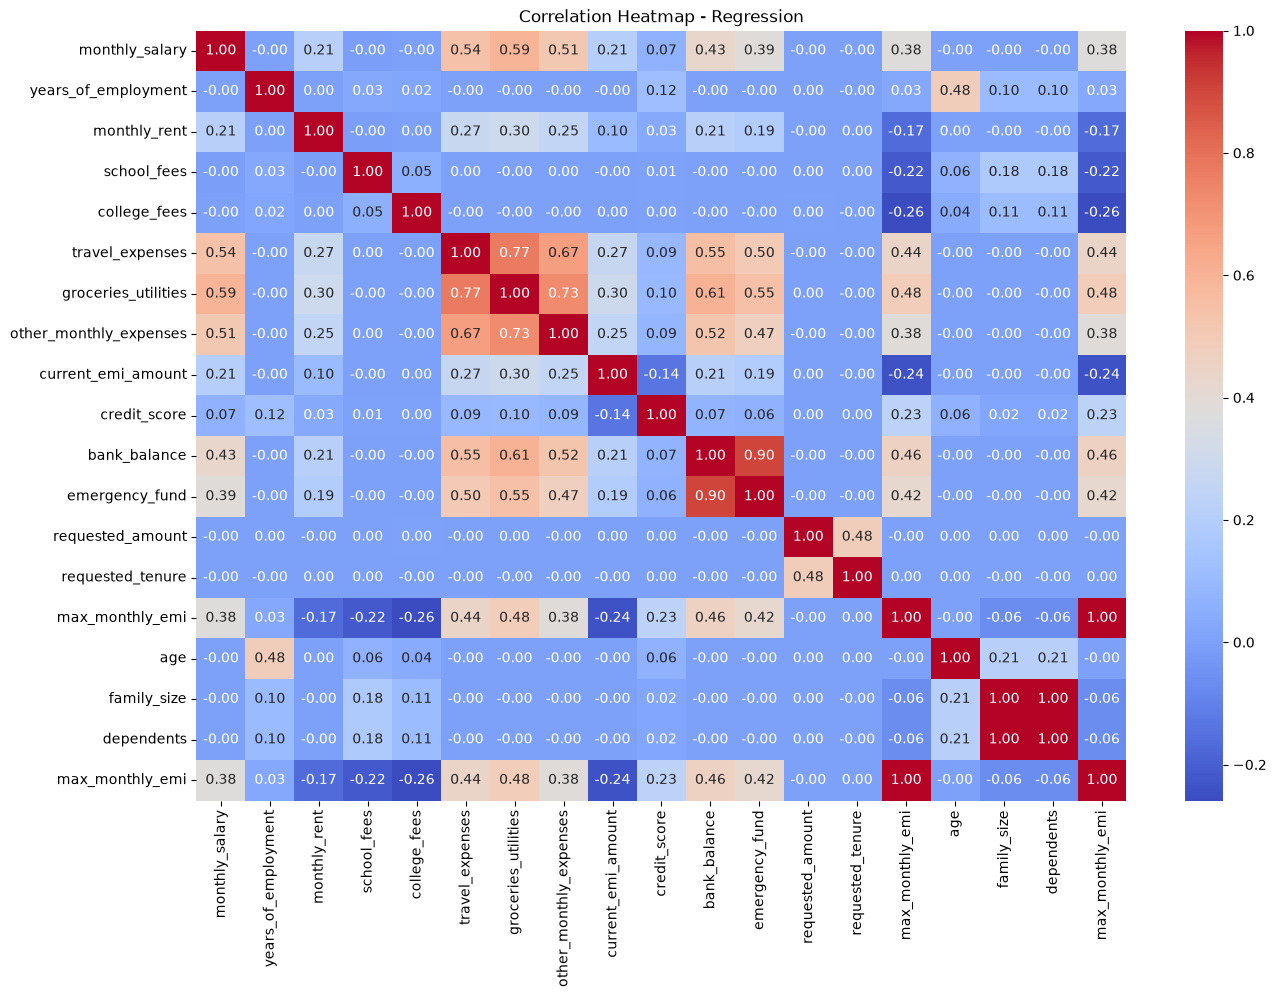

In [131]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Regression")
plt.show()

In [142]:
corr_matrix = dataset[regression_features].corr()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        correlation = corr_matrix.iloc[i, j]

        if abs(correlation) > 0.50:
            print(
                f"{corr_matrix.columns[i]} <--> "
                f"{corr_matrix.columns[j]} : "
                f"{correlation:.4f}"
            )

KeyError: "['dependents'] not in index"

In [139]:
features_for_vif = [
    feature
    for feature in (continuous_features + discrete_feature)
    if feature not in ["dependents", "max_monthly_emi"]
]

X = dataset[features_for_vif].copy()

X = X.apply(pd.to_numeric, errors="coerce").astype(float)
X = X.replace([np.inf, -np.inf], np.nan).dropna()

vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,Feature,VIF
9,credit_score,22.482316
14,age,20.940293
10,bank_balance,16.571580
6,groceries_utilities,15.552008
11,emergency_fund,13.025391
5,travel_expenses,10.430497
15,family_size,8.898689
7,other_monthly_expenses,8.081057
0,monthly_salary,4.649533
13,requested_tenure,4.593076


In [140]:
dataset.drop("dependents", axis=1, inplace=True)

#### Multivariate analysis using correlation and VIF identified the presence of multicollinearity among several numerical features. dependents and family_size have a perfect correlation of 1.0000, indicating redundant information, while bank_balance and emergency_fund have a strong positive correlation of 0.9025. VIF analysis further identified high multicollinearity in credit_score, age, bank_balance, groceries_utilities, emergency_fund, and travel_expenses, while family_size and other_monthly_expenses showed moderate multicollinearity. Therefore, these features should be considered during the feature-selection stage rather than being removed solely on the basis of correlation.

In [145]:
classification_features = [
    feature
    for feature in (continuous_features + discrete_feature)
    if feature != "dependents"
]

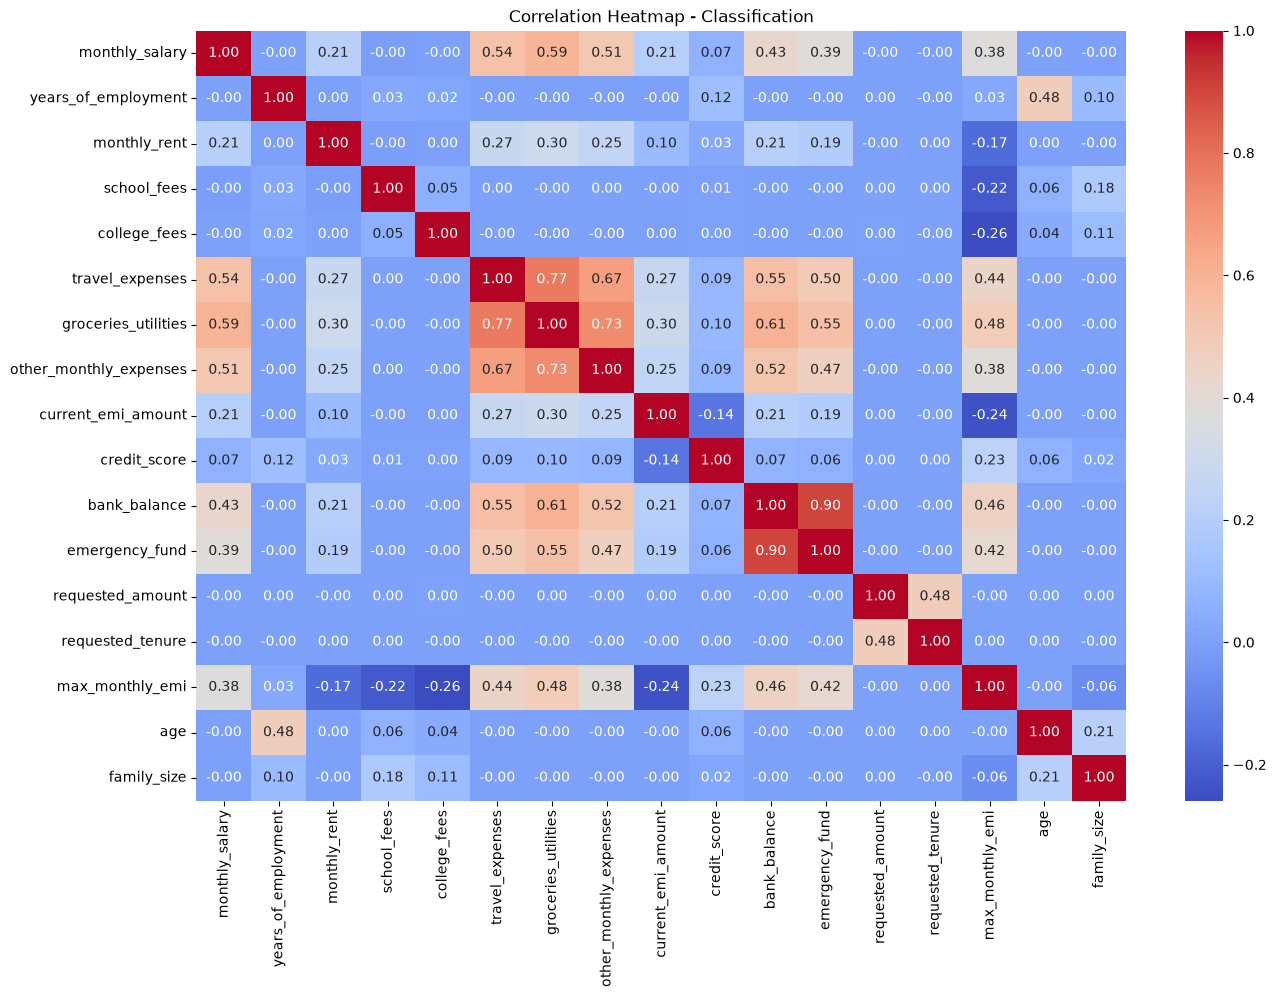

In [146]:
corr_matrix = dataset[classification_features].corr()

plt.figure(figsize=(15, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Classification")
plt.show()

In [147]:
corr_matrix = dataset[classification_features].corr()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        correlation = corr_matrix.iloc[i, j]

        if abs(correlation) > 0.80:
            print(
                f"{corr_matrix.columns[i]} <--> "
                f"{corr_matrix.columns[j]} : "
                f"{correlation:.4f}"
            )

emergency_fund <--> bank_balance : 0.9025


In [148]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = dataset[classification_features].copy()

X = X.apply(pd.to_numeric, errors="coerce").astype(float)
X = X.replace([np.inf, -np.inf], np.nan).dropna()

vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,Feature,VIF
9,credit_score,23.123768
15,age,20.979371
10,bank_balance,17.173084
6,groceries_utilities,17.157275
11,emergency_fund,13.025437
5,travel_expenses,10.741301
16,family_size,8.907019
7,other_monthly_expenses,8.086904
14,max_monthly_emi,5.870204
0,monthly_salary,4.801189


#### VIF analysis indicates substantial multicollinearity among several numerical features. credit_score, age, bank_balance, groceries_utilities, emergency_fund, and travel_expenses have VIF values above 10, indicating high multicollinearity. family_size, other_monthly_expenses, and max_monthly_emi show moderate multicollinearity, while the remaining features have relatively low VIF values. These features should be considered during the feature-selection stage rather than being removed solely based on their VIF values.

In [149]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

In [150]:
for feature in categorical_features:
    score = cramers_v(
        dataset[feature],
        dataset["emi_eligibility"]
    )
    
    print(f"{feature}: {score:.4f}")

gender: 0.0002
marital_status: 0.0365
education: 0.0998
employment_type: 0.0296
company_type: 0.0024
house_type: 0.1443
existing_loans: 0.2552
emi_scenario: 0.1307
emi_eligibility: 1.0000


In [151]:
dataset.to_csv("dataset.csv",index=True)

# Feature Engineering 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df=pd.read_csv("dataset.csv")

In [4]:
df.shape

(404800, 27)

In [6]:
df.columns

Index(['Unnamed: 0', 'age', 'gender', 'marital_status', 'education',
       'monthly_salary', 'employment_type', 'years_of_employment',
       'company_type', 'house_type', 'monthly_rent', 'family_size',
       'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='str')

In [7]:
df.head()

,Unnamed: 0,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [9]:
df.drop('Unnamed: 0',inplace=True,axis=1)

In [10]:
df.shape

(404800, 26)

In [11]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404797 non-null  float64
 1   gender                  404800 non-null  str    
 2   marital_status          404800 non-null  str    
 3   education               402396 non-null  str    
 4   monthly_salary          402807 non-null  float64
 5   employment_type         404800 non-null  str    
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  str    
 8   house_type              404800 non-null  str    
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  school_fees             404800 non-null  float64
 12  college_fees            404800 non-null  float64
 13  travel_expenses         404800 non-null  float64
 14  groceries_utilities     404800 

In [14]:
from sklearn.model_selection import train_test_split

In [16]:
x=df.drop(['emi_eligibility', 'max_monthly_emi'],axis=1)
y=df['max_monthly_emi']

In [17]:
x.shape

(404800, 24)

In [18]:
y.shape

(404800,)

In [19]:
x.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7


In [20]:
y.head()

0      500.0
1      700.0
2    27775.0
3    16170.0
4      500.0
Name: max_monthly_emi, dtype: float64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape

(323840, 24)

In [24]:
y_train.shape

(323840,)

In [25]:
X_test.shape

(80960, 24)

In [26]:
y_test.shape

(80960,)

## Missing value handling 

In [30]:
feature_nan=[feature for feature in X_train.columns if X_train[feature].isnull().sum()>1]

In [31]:
feature_nan

['age',
 'education',
 'monthly_salary',
 'monthly_rent',
 'credit_score',
 'bank_balance',
 'emergency_fund']